# Import Required Libraries

In [12]:
import uuid
import copy
from datetime import datetime
from pathlib import Path
import getpass
import copy
import pandas as pd
import numpy as np
import json
import pickle
import re
import os
import glob
from typing import Dict, List, Optional, Any, Tuple
from tqdm.notebook import tqdm
import time

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML
import ipywidgets as widgets

pd.options.display.max_colwidth = 300

# Configuration Settings

In [13]:
# Project setup
DATA_DIR = Path("/global/homes/b/bkieft/metatlas2/data/")
DATABASES_DIR = DATA_DIR / "databases"
PROJECT = "20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519"
PROJECT_DIR = DATA_DIR / "tests/projects" / PROJECT

# Experimental H5 Files Configuration
EXPERIMENTAL_FILE_PATH = PROJECT_DIR / "lcmsruns"  # Base path to search for QC files
MIN_EXPERIMENTAL_FILES = 1  # Minimum number of experimental files required

# RT-Corrected Atlas Configuration
RT_CORRECTED_ATLAS_PATH = DATABASES_DIR / "atlases" / "rtc-istd-atlas-HILIC-positive-8af25e856fe742c3.json"

# Compounds, LCMS Runs, and MZ/RT References Databases
COMPOUNDS_DATA_PATH = DATABASES_DIR / "compounds/Compounds.json"
MZ_RT_REFERENCES_DATA_PATH = DATABASES_DIR / "mz_rt_references/MZ_RT_References.json"
LCMS_RUNS_DATA_PATH = DATABASES_DIR / "lcmsruns/LCMS_Runs.json"
MSMS_REFS_PATH = DATABASES_DIR / "msms_refs/msms_refs.tab"

# Analysis Parameters
DEFAULT_MZ_TOLERANCE_PPM = 5.0  # Default m/z tolerance in ppm
USE_ATLAS_MZ_TOLERANCE = True   # Use mz_tolerance from Atlas if available
RT_WINDOW_EXPANSION = 0         # Extra RT window (minutes) around corrected RT for peak search
MIN_PEAK_INTENSITY = 1e5        # Minimum peak intensity for consideration

# Output Configuration
OUTPUT_DIR = DATA_DIR / "targeted_results/"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPORT_FORMATS = ['csv', 'json']  # Export formats
INCLUDE_PLOTS = True              # Generate summary plots
ANALYST_NAME = getpass.getuser()

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Configuration set:")
print(f"  RT-corrected Atlas directory: {RT_CORRECTED_ATLAS_PATH}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Default m/z tolerance: {DEFAULT_MZ_TOLERANCE_PPM} ppm")
print(f"  RT search window: ±{RT_WINDOW_EXPANSION} min")
print(f"  Analyst: {ANALYST_NAME}")
print(f"  Timestamp: {TIMESTAMP}")

Configuration set:
  RT-corrected Atlas directory: /global/homes/b/bkieft/metatlas2/data/databases/atlases/rtc-istd-atlas-HILIC-positive-8af25e856fe742c3.json
  Output directory: /global/homes/b/bkieft/metatlas2/data/targeted_results
  Default m/z tolerance: 5.0 ppm
  RT search window: ±0 min
  Analyst: bkieft
  Timestamp: 20250812_090358


# Define helper functions

In [14]:
# Import feature_tools
import sys
sys.path.append('/global/homes/b/bkieft/metatlas/')
from metatlas.io import feature_tools as ft

def load_json_file(file_path):
    """Load a JSON file and return its content."""
    with open(file_path, 'r') as f:
        return json.load(f)

def convert_atlas_json_to_dataframe(rtc_atlas_data, compounds_db, mz_rt_experimental_data):
    """
    Convert flattened Atlas JSON to DataFrame format required by feature_tools.py
    
    Args:
        rtc_atlas_data: Your flattened Atlas JSON object
        compounds_db: Compounds database lookup
        mz_rt_experimental_data: MZ/RT experimental data lookup
    
    Returns:
        pandas.DataFrame: Atlas DataFrame in format expected by feature_tools.get_data()
    """
    atlas_rows = []
    
    # Extract atlas metadata
    polarity = rtc_atlas_data.get('method', {}).get('polarity', 'positive')
    
    for compound_entry in rtc_atlas_data['compounds']:
        compound_uid = compound_entry['compound_uid']
        mz_rt_ref_uid = compound_entry['mz_rt_reference_uid']
        mz_rt_exp_uid = compound_entry['mz_rt_experimental_uid']
        
        # Get compound info from compounds_db
        compound_info = compounds_db.get(compound_uid, {})
        compound_name = compound_info.get('name', f'Unknown_{compound_uid[:8]}')
        
        # Get experimental MZ/RT data
        exp_data = mz_rt_experimental_data.get(mz_rt_exp_uid, {})
        
        # Create atlas row with required columns for feature_tools
        atlas_row = {
            'label': compound_name,                              # Compound label/name
            'mz': exp_data.get('mz', 0.0),                      # m/z value
            'rt_min': exp_data.get('rt_min', 0.0),              # RT minimum
            'rt_max': exp_data.get('rt_max', 0.0),              # RT maximum  
            'rt_peak': exp_data.get('rt_peak', 0.0),            # RT peak center
            'mz_tolerance': exp_data.get('mz_tolerance', 5.0),   # m/z tolerance in ppm
            
            # Optional but useful metadata
            'compound_uid': compound_uid,
            'mz_rt_reference_uid': mz_rt_ref_uid,
            'mz_rt_experimental_uid': mz_rt_exp_uid,
            'polarity': polarity,
            'inchi_key': compound_info.get('inchi_key', ''),
            'adduct': exp_data.get('adduct', '[M+H]+' if polarity == 'positive' else '[M-H]-')
        }
        
        atlas_rows.append(atlas_row)
    
    # Convert to DataFrame
    atlas_df = pd.DataFrame(atlas_rows)
    
    # Ensure required columns have correct data types
    numeric_columns = ['mz', 'rt_min', 'rt_max', 'rt_peak', 'mz_tolerance']
    for col in numeric_columns:
        if col in atlas_df.columns:
            atlas_df[col] = pd.to_numeric(atlas_df[col], errors='coerce')
    
    # Remove rows with missing critical data
    atlas_df = atlas_df.dropna(subset=['mz', 'rt_min', 'rt_max', 'rt_peak'])
    
    return atlas_df

def prepare_feature_tools_inputs(atlas_df, h5_files, polarity='positive', 
                                ppm_tolerance=20, extra_time=0.1):
    """
    Prepare input parameters for feature_tools.get_data() function using setup_file_slicing_parameters
    
    Args:
        atlas_df: Atlas DataFrame with required columns
        h5_files: List of H5 file paths
        polarity: 'positive' or 'negative'
        ppm_tolerance: m/z tolerance in ppm (default: 20)
        extra_time: Additional time window in minutes (default: 0.1)
    
    Returns:
        List of input dictionaries for feature_tools.get_data()
    """

    # Use setup_file_slicing_parameters to prepare inputs
    input_data_list = ft.setup_file_slicing_parameters(
        atlas=atlas_df,
        filenames=h5_files,
        extra_time=extra_time,
        ppm_tolerance=ppm_tolerance,
        polarity=polarity,
        project_dir=False,  # Don't save intermediate files
        overwrite=True
    )
    
    return input_data_list

def extract_eic_and_ms2_data(input_data_list, atlas_df):
    """    
    Args:
        input_data_list: List of input dictionaries from setup_file_slicing_parameters
        atlas_df: Atlas DataFrame containing compound metadata including inchi_key
    
    Returns:
        Tuple: (eics_dict, ms2_data_dict)
            - eics_dict: Dictionary mapping file paths to grouped EIC data with inchi_key
            - ms2_data_dict: Dictionary mapping file paths to MS2 summary data with inchi_key and sorted by intensity
    """
    eics = {}
    ms2_data = {}
    
    # Create a mapping from compound label to metadata
    compound_metadata = {}
    for _, row in atlas_df.iterrows():
        compound_metadata[row['label']] = {
            'inchi_key': row.get('inchi_key', ''),
            'compound_uid': row.get('compound_uid', ''),
            'adduct': row.get('adduct', ''),
            'mz': row.get('mz', 0.0),
            'rt_min': row.get('rt_min', 0.0),
            'rt_max': row.get('rt_max', 0.0),
            'rt_peak': row.get('rt_peak', 0.0)
        }
    
    print(f"Extracting enhanced EIC and MS2 data from {len(input_data_list)} files...")
    print(f"Using metadata for {len(compound_metadata)} compounds from atlas...")
    
    for i, file_input in enumerate(tqdm(input_data_list, desc="Processing enhanced data")):
        file_path = file_input['lcmsrun']
        file_name = Path(file_path).name
        
        try:
            # Extract data with ms1_feature_filter=False to get all data
            data = ft.get_data(file_input, save_file=False, return_data=True, ms1_feature_filter=False)
            
            # Group duplicates to create adduct EICs
            if not data['ms1_data'].empty:
                adduct_eics = ft.group_duplicates(data['ms1_data'], 'label', make_string=False)
                
                # Add inchi_key column to EIC data
                if not adduct_eics.empty and 'label' in adduct_eics.columns:
                    # Map compound labels to inchi_keys
                    adduct_eics['inchi_key'] = adduct_eics['label'].map(
                        lambda x: compound_metadata.get(x, {}).get('inchi_key', '')
                    )
                    
                    # Add other useful metadata
                    adduct_eics['compound_uid'] = adduct_eics['label'].map(
                        lambda x: compound_metadata.get(x, {}).get('compound_uid', '')
                    )
                    adduct_eics['adduct'] = adduct_eics['label'].map(
                        lambda x: compound_metadata.get(x, {}).get('adduct', '')
                    )

                    # Calculate rt_peak for each row: the RT at which intensity is maximal
                    def calc_best_rt_and_i(row):
                        intensities = row.get('i', None)
                        rts = row.get('rt', None)
                        mzs = row.get('mz', None)
                        if isinstance(intensities, (np.ndarray, list)) and isinstance(rts, (np.ndarray, list)):
                            if len(intensities) > 0 and len(rts) > 0:
                                max_idx = np.argmax(intensities)
                                return pd.Series({'rt_peak': rts[max_idx], 'intensity_peak': intensities[max_idx], 'mz_peak': mzs[max_idx]})
                        return pd.Series({'rt_peak': np.nan, 'intensity_peak': np.nan, 'mz_peak': np.nan})

                    best_rt_i = adduct_eics.apply(calc_best_rt_and_i, axis=1)
                    adduct_eics['rt_peak'] = best_rt_i['rt_peak']
                    adduct_eics['intensity_peak'] = best_rt_i['intensity_peak']
                    adduct_eics['mz_peak'] = best_rt_i['mz_peak']
                    adduct_eics.sort_values(by='rt_peak', inplace=True)

                eics[file_path] = adduct_eics
                print(f"  {i+1}/{len(input_data_list)}: {file_name} -> EIC data extracted ({len(adduct_eics)} compounds)")
            else:
                print(f"  {i+1}/{len(input_data_list)}: {file_name} -> No MS1 data found")
            
            # Calculate MS2 summary
            if not data['ms2_data'].empty:
                ms2_summary = ft.calculate_ms2_summary(data['ms2_data'])
                if not ms2_summary.empty:
                    # Add inchi_key column to MS2 data
                    if 'label' in ms2_summary.columns:
                        ms2_summary['inchi_key'] = ms2_summary['label'].map(
                            lambda x: compound_metadata.get(x, {}).get('inchi_key', '')
                        )
                        
                        # Add other useful metadata
                        ms2_summary['compound_uid'] = ms2_summary['label'].map(
                            lambda x: compound_metadata.get(x, {}).get('compound_uid', '')
                        )
                        ms2_summary['adduct'] = ms2_summary['label'].map(
                            lambda x: compound_metadata.get(x, {}).get('adduct', '')
                        )
                    
                    # Ensure MS2 data has intensity column and sort by it
                    # Check if intensity column exists, if not try to find one
                    intensity_col = None
                    potential_intensity_cols = ['intensity', 'i', 'peak_height', 'precursor_intensity', 'base_peak_intensity']
                    
                    for col in potential_intensity_cols:
                        if col in ms2_summary.columns:
                            intensity_col = col
                            break
                    
                    if intensity_col is None:
                        # If no standard intensity column found, check for numeric columns that might be intensity
                        numeric_cols = ms2_summary.select_dtypes(include=[np.number]).columns
                        intensity_candidates = [col for col in numeric_cols if 'int' in col.lower() or 'height' in col.lower() or 'area' in col.lower()]
                        if intensity_candidates:
                            intensity_col = intensity_candidates[0]
                    
                    if intensity_col is not None:
                        # Sort by intensity in descending order
                        ms2_summary = ms2_summary.sort_values(by=intensity_col, ascending=False)
                        print(f"    MS2 summary: {len(ms2_summary)} spectra")
                    else:
                        # If no intensity column found, create a placeholder and add a warning
                        ms2_summary['intensity'] = 1.0  # Placeholder intensity
                        print(f"    MS2 summary: {len(ms2_summary)} spectra (no intensity column found, added placeholder)")
                    
                    ms2_data[file_path] = ms2_summary
                else:
                    print(f"    MS2 summary: No valid spectra")
            else:
                print(f"    MS2: No data found")
                
        except Exception as e:
            print(f"  {i+1}/{len(input_data_list)}: {file_name} -> ERROR: {e}")
            continue

    print(f"\nExtraction complete:")
    print(f"  EIC data: {len(eics)} files")
    print(f"  MS2 data: {len(ms2_data)} files")
    
    return eics, ms2_data


def load_msms_refs_file(file_path):
    """
    Load the msms_refs.tab file and convert it to a DataFrame format suitable for MS2 matching.
    
    Args:
        file_path: Path to the msms_refs.tab file
        
    Returns:
        DataFrame with columns: ['database', 'id', 'name', 'spectrum', 'collision_energy', 
                                'precursor_mz', 'polarity', 'adduct', 'formula', 'exact_mass', 
                                'inchi_key', 'inchi', 'smiles']
    """
    import ast
    
    # Read the tab-separated file
    df = pd.read_csv(file_path, sep='\t', header=None, names=[
        'id', 'database', 'compound_id', 'name', 'spectrum', 'collision_energy', 
        'precursor_mz', 'polarity', 'adduct', 'fragmentation_method', 'other_id', 
        'experiment', 'instrument', 'formula', 'exact_mass', 'inchi_key', 'inchi', 'smiles'
    ])
    
    # Convert spectrum strings to numpy arrays
    def parse_spectrum(spec_str):
        try:
            # Parse the string representation of the spectrum
            spectrum = ast.literal_eval(spec_str)
            if len(spectrum) == 2 and len(spectrum[0]) == len(spectrum[1]):
                return np.array(spectrum)
            else:
                return None
        except:
            return None
    
    df['spectrum_parsed'] = df['spectrum'].apply(parse_spectrum)
    
    # Remove rows with unparseable spectra
    df = df.dropna(subset=['spectrum_parsed'])
    df['spectrum'] = df['spectrum_parsed']
    df = df.drop('spectrum_parsed', axis=1)
    
    # Clean up data types
    df['precursor_mz'] = pd.to_numeric(df['precursor_mz'], errors='coerce')
    df['collision_energy'] = pd.to_numeric(df['collision_energy'], errors='coerce') 
    df['exact_mass'] = pd.to_numeric(df['exact_mass'], errors='coerce')
    
    return df

def get_ms2_hits_from_data(ms2_data_dict, reference_df, 
                          frag_mz_tolerance=0.005, 
                          keep_nonmatches=True,
                          precursor_mz_tolerance_ppm=10.0):
    """
    Get MS2 hits from your ms2_data object using a reference DataFrame.
    
    Updated to use metatlas-style alignment with matchms Spectrum objects and cosine similarity
    for consistency with existing metatlas workflows while leveraging matchms capabilities.
    
    Args:
        ms2_data_dict: Dictionary with file paths as keys and DataFrames as values
                      Each DataFrame should have columns from ft.calculate_ms2_summary():
                      ['label', 'spectrum', 'rt', 'precursor_mz', 'precursor_intensity', 
                       'inchi_key', 'compound_uid', 'adduct']
        reference_df: DataFrame from load_msms_refs_file() with columns:
                     ['database', 'id', 'name', 'spectrum', 'precursor_mz', 'inchi_key', ...]
        frag_mz_tolerance: m/z tolerance for fragment matching (default: 0.005)
        keep_nonmatches: Whether to keep entries without reference matches (default: True)
        precursor_mz_tolerance_ppm: Precursor m/z tolerance in ppm (default: 10.0)
        
    Returns:
        DataFrame with MS2 hits in the same format as get_msms_hits()
        Columns: ['database', 'id', 'file_name', 'msms_scan', 'score', 'num_matches',
                 'ref_frags', 'data_frags', 'msv_query_aligned', 'msv_ref_aligned', 
                 'name', 'adduct', 'inchi_key', 'precursor_mz', 'measured_precursor_mz',
                 'measured_precursor_intensity']
    """
    from matchms import Spectrum
    from matchms.similarity import CosineHungarian
    import numpy as np
    
    def align_all_ms_vectors_metatlas_style(query_mz, query_intensity, ref_mz, ref_intensity, mz_tolerance=0.005):
        """
        Align MS2 vectors using the metatlas approach for consistent fragment matching.
        This creates aligned arrays where each position represents the same m/z value.
        
        Args:
            query_mz: Query spectrum m/z values
            query_intensity: Query spectrum intensities
            ref_mz: Reference spectrum m/z values  
            ref_intensity: Reference spectrum intensities
            mz_tolerance: m/z tolerance for matching (default: 0.005)
            
        Returns:
            tuple: (aligned_query_mz, aligned_query_intensity, aligned_ref_mz, aligned_ref_intensity, num_matches)
        """
        # Convert to numpy arrays and ensure they're sorted
        query_mz = np.array(query_mz, dtype=np.float64)
        query_intensity = np.array(query_intensity, dtype=np.float64)
        ref_mz = np.array(ref_mz, dtype=np.float64)
        ref_intensity = np.array(ref_intensity, dtype=np.float64)
        
        # Sort both spectra by m/z
        query_sort_idx = np.argsort(query_mz)
        query_mz = query_mz[query_sort_idx]
        query_intensity = query_intensity[query_sort_idx]
        
        ref_sort_idx = np.argsort(ref_mz)
        ref_mz = ref_mz[ref_sort_idx]
        ref_intensity = ref_intensity[ref_sort_idx]
        
        # Get all unique m/z values from both spectra
        all_mz = np.concatenate([query_mz, ref_mz])
        all_mz_unique = np.unique(all_mz)
        
        # Initialize aligned arrays
        aligned_query_mz = []
        aligned_query_intensity = []
        aligned_ref_mz = []
        aligned_ref_intensity = []
        num_matches = 0
        
        for target_mz in all_mz_unique:
            # Find query peaks within tolerance
            query_matches = np.abs(query_mz - target_mz) <= mz_tolerance
            query_intensities = query_intensity[query_matches]
            
            # Find reference peaks within tolerance  
            ref_matches = np.abs(ref_mz - target_mz) <= mz_tolerance
            ref_intensities = ref_intensity[ref_matches]
            
            # Use the maximum intensity if multiple peaks match
            query_max_intensity = np.max(query_intensities) if len(query_intensities) > 0 else 0.0
            ref_max_intensity = np.max(ref_intensities) if len(ref_intensities) > 0 else 0.0
            
            # Only include if at least one spectrum has a peak
            if query_max_intensity > 0 or ref_max_intensity > 0:
                aligned_query_mz.append(target_mz)
                aligned_query_intensity.append(query_max_intensity)
                aligned_ref_mz.append(target_mz)
                aligned_ref_intensity.append(ref_max_intensity)
                
                # Count as match if both spectra have intensity > 0
                if query_max_intensity > 0 and ref_max_intensity > 0:
                    num_matches += 1
        
        return (np.array(aligned_query_mz), np.array(aligned_query_intensity),
                np.array(aligned_ref_mz), np.array(aligned_ref_intensity), num_matches)
    
    # Initialize the matchms similarity scorer
    cos = CosineHungarian(tolerance=frag_mz_tolerance)
    
    # Columns for the output DataFrame (matching get_msms_hits format)
    msms_hits_cols = ['database', 'id', 'file_name', 'msms_scan', 'score', 'num_matches',
                     'ref_frags', 'data_frags',
                     'msv_query_aligned', 'msv_ref_aligned', 'name', 'adduct', 'inchi_key',
                     'precursor_mz', 'measured_precursor_mz',
                     'measured_precursor_intensity']
    
    all_hits = []
    
    # Process each file
    for file_path, ms2_df in tqdm(ms2_data_dict.items(), desc="Processing MS2 files"):
        file_name = Path(file_path).name
        
        # Process each spectrum in the file
        for idx, row in ms2_df.iterrows():
            # Extract spectrum data - handle different possible column names
            spectrum_data = None
            for col in ['spectrum', 'spectra', 'ms2_spectrum']:
                if col in row and row[col] is not None:
                    spectrum_data = row[col]
                    break
            
            if spectrum_data is None:
                continue
                
            # Parse spectrum data format from ft.calculate_ms2_summary
            try:
                if isinstance(spectrum_data, (list, tuple)) and len(spectrum_data) == 2:
                    mz_values = np.array(spectrum_data[0], dtype=np.float64)
                    intensity_values = np.array(spectrum_data[1], dtype=np.float64)
                elif isinstance(spectrum_data, np.ndarray) and spectrum_data.shape[0] == 2:
                    mz_values = np.array(spectrum_data[0], dtype=np.float64)
                    intensity_values = np.array(spectrum_data[1], dtype=np.float64)
                else:
                    continue
            except:
                continue
            
            if len(mz_values) == 0 or len(intensity_values) == 0:
                continue
            
            # Get precursor m/z - handle different possible column names
            precursor_mz = None
            for col in ['precursor_mz', 'mz', 'parent_mz']:
                if col in row and not pd.isna(row[col]):
                    precursor_mz = float(row[col])
                    break
            
            if precursor_mz is None:
                continue
            
            # Get precursor intensity - handle different possible column names
            precursor_intensity = 1.0  # Default
            for col in ['precursor_intensity', 'intensity', 'precursor_peak_height', 'base_peak_intensity']:
                if col in row and not pd.isna(row[col]):
                    precursor_intensity = float(row[col])
                    break
            
            # Get RT value - handle different possible column names
            rt_value = 0.0  # Default
            for col in ['rt', 'retention_time', 'scan_time']:
                if col in row and not pd.isna(row[col]):
                    rt_value = float(row[col])
                    break
            
            # Create matchms Spectrum object for the query
            query_spectrum = Spectrum(mz=mz_values, 
                                    intensities=intensity_values,
                                    metadata={'precursor_mz': precursor_mz})
            
            # Get inchi_key for matching
            inchi_key = row.get('inchi_key', '')
            if pd.isna(inchi_key):
                inchi_key = ''
            
            # Find matching reference spectra
            if inchi_key == '':
                if keep_nonmatches:
                    # Create a non-match entry
                    hit = {
                        'database': None,
                        'id': None,
                        'file_name': file_name,
                        'msms_scan': rt_value,
                        'score': 0.0,
                        'num_matches': 0,
                        'ref_frags': 0,
                        'data_frags': len(mz_values),
                        'msv_query_aligned': np.array([mz_values, intensity_values]),
                        'msv_ref_aligned': np.array([[], []]),
                        'name': row.get('label', 'Unknown'),
                        'adduct': row.get('adduct', ''),
                        'inchi_key': inchi_key,
                        'precursor_mz': np.nan,
                        'measured_precursor_mz': precursor_mz,
                        'measured_precursor_intensity': precursor_intensity
                    }
                    all_hits.append(hit)
                continue
            
            # Find reference spectra with matching inchi_key
            matching_refs = reference_df[reference_df['inchi_key'] == inchi_key]
            
            if matching_refs.empty:
                if keep_nonmatches:
                    # Create a non-match entry
                    hit = {
                        'database': 'no_match',
                        'id': f'no_match_{inchi_key}',
                        'file_name': file_name,
                        'msms_scan': rt_value,
                        'score': 0.0,
                        'num_matches': 0,
                        'ref_frags': 0,
                        'data_frags': len(mz_values),
                        'msv_query_aligned': np.array([mz_values, intensity_values]),
                        'msv_ref_aligned': np.array([[], []]),
                        'name': row.get('label', 'Unknown'),
                        'adduct': row.get('adduct', ''),
                        'inchi_key': inchi_key,
                        'precursor_mz': np.nan,
                        'measured_precursor_mz': precursor_mz,
                        'measured_precursor_intensity': precursor_intensity
                    }
                    all_hits.append(hit)
                continue
            
            # Compare against each matching reference spectrum
            for _, ref_row in matching_refs.iterrows():
                # Extract reference spectrum data
                ref_spectrum_data = ref_row.get('spectrum', None)
                if ref_spectrum_data is None:
                    continue
                
                # Handle reference spectrum format
                try:
                    if isinstance(ref_spectrum_data, np.ndarray) and ref_spectrum_data.shape[0] == 2:
                        ref_mz = np.array(ref_spectrum_data[0], dtype=np.float64)
                        ref_intensity = np.array(ref_spectrum_data[1], dtype=np.float64)
                    elif isinstance(ref_spectrum_data, (list, tuple)) and len(ref_spectrum_data) == 2:
                        ref_mz = np.array(ref_spectrum_data[0], dtype=np.float64)
                        ref_intensity = np.array(ref_spectrum_data[1], dtype=np.float64)
                    else:
                        continue
                except:
                    continue
                
                if len(ref_mz) == 0 or len(ref_intensity) == 0:
                    continue
                
                # Check precursor m/z tolerance if available
                ref_precursor_mz = ref_row.get('precursor_mz', np.nan)
                if not pd.isna(ref_precursor_mz):
                    ppm_error = abs(precursor_mz - ref_precursor_mz) / ref_precursor_mz * 1e6
                    if ppm_error > precursor_mz_tolerance_ppm:
                        continue
                
                # Create matchms Spectrum object for the reference
                ref_spectrum = Spectrum(mz=ref_mz, 
                                      intensities=ref_intensity,
                                      metadata={'precursor_mz': ref_precursor_mz})
                
                # Calculate similarity score using matchms
                try:
                    similarity_result = cos.pair(query_spectrum, ref_spectrum)
                    score = float(similarity_result['score'])
                    matchms_matches = int(similarity_result['matches'])
                except Exception as e:
                    print(f"Error calculating similarity with matchms: {e}")
                    score = 0.0
                    matchms_matches = 0
                
                # Align MS vectors using metatlas approach for consistent output format
                try:
                    (aligned_query_mz, aligned_query_intensity,
                     aligned_ref_mz, aligned_ref_intensity, metatlas_matches) = align_all_ms_vectors_metatlas_style(
                        mz_values, intensity_values, ref_mz, ref_intensity, frag_mz_tolerance
                    )
                    
                    # Use metatlas matches for consistency with existing workflows
                    num_matches = metatlas_matches
                    
                except Exception as e:
                    print(f"Error aligning spectra: {e}")
                    num_matches = matchms_matches  # Fallback to matchms matches
                    aligned_query_mz = mz_values
                    aligned_query_intensity = intensity_values
                    aligned_ref_mz = ref_mz
                    aligned_ref_intensity = ref_intensity
                
                # Create hit entry
                hit = {
                    'database': ref_row.get('database', 'unknown'),
                    'id': str(ref_row.get('id', f'ref_{ref_row.name}')),
                    'file_name': file_name,
                    'msms_scan': rt_value,
                    'score': float(score),  # matchms cosine score
                    'num_matches': int(num_matches),  # metatlas-style matches
                    'ref_frags': len(ref_mz),
                    'data_frags': len(mz_values),
                    'msv_query_aligned': np.array([aligned_query_mz, aligned_query_intensity]),
                    'msv_ref_aligned': np.array([aligned_ref_mz, aligned_ref_intensity]),
                    'name': ref_row.get('name', row.get('label', 'Unknown')),
                    'adduct': ref_row.get('adduct', row.get('adduct', '')),
                    'inchi_key': inchi_key,
                    'precursor_mz': float(ref_precursor_mz) if not pd.isna(ref_precursor_mz) else np.nan,
                    'measured_precursor_mz': precursor_mz,
                    'measured_precursor_intensity': precursor_intensity
                }
                all_hits.append(hit)
    
    # Convert to DataFrame
    if not all_hits:
        return pd.DataFrame(columns=msms_hits_cols).set_index(['database', 'id', 'file_name', 'msms_scan'])
    
    hits_df = pd.DataFrame(all_hits)
    
    # Ensure numeric columns are properly typed
    numeric_cols = ['score', 'num_matches', 'ref_frags', 'data_frags', 'msms_scan', 
                   'precursor_mz', 'measured_precursor_mz', 'measured_precursor_intensity']
    for col in numeric_cols:
        if col in hits_df.columns:
            hits_df[col] = pd.to_numeric(hits_df[col], errors='coerce')
    
    # Filter out non-matches if requested
    if not keep_nonmatches:
        hits_df = hits_df.dropna(subset=['database', 'id'], how='all')
    
    # Set the index to match get_msms_hits format
    if not hits_df.empty:
        hits_df = hits_df.set_index(['database', 'id', 'file_name', 'msms_scan'])
    else:
        hits_df = pd.DataFrame(columns=msms_hits_cols).set_index(['database', 'id', 'file_name', 'msms_scan'])
    
    return hits_df

def load_reference_data_from_json(json_path):
    """
    Load reference spectral data from a JSON file.
    Expected format similar to the frag_refs.json used by get_msms_hits()
    
    Args:
        json_path: Path to JSON file containing reference spectra
        
    Returns:
        DataFrame with columns: ['database', 'id', 'inchi_key', 'name', 'precursor_mz', 'adduct', 'spectrum']
    """
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    ref_data = []
    for i in range(len(data['inchi_key'])):
        spectrum_array = np.array(data['mz_intensities'][i]).T  # Convert [(mz, int), ...] to [[mz...], [int...]]
        
        ref_entry = {
            'database': 'metatlas',  # or from data if available
            'id': data.get('head_id', [f'ref_{i}'])[i],
            'inchi_key': data['inchi_key'][i],
            'name': f"compound_{i}",  # Update if compound names are available
            'precursor_mz': data['precursor_mz'][i],
            'adduct': f"{data['polarity'][i]} mode",  # Update based on your adduct format
            'spectrum': spectrum_array
        }
        ref_data.append(ref_entry)
    
    return pd.DataFrame(ref_data)

def analyze_ms2_hits_results(hits_df, min_score=0.5, min_matches=3):
    """
    Analyze the results from get_msms_hits_from_data()
    
    Args:
        hits_df: DataFrame returned by get_msms_hits_from_data()
        min_score: Minimum score threshold for good matches
        min_matches: Minimum number of matching fragments
        
    Returns:
        Dictionary with analysis results
    """
    if hits_df.empty:
        return {"message": "No hits found"}
    
    analysis = {}
    
    # Reset index to access index columns as regular columns
    hits_reset = hits_df.reset_index()
    
    # Basic statistics
    analysis['total_hits'] = len(hits_df)
    analysis['unique_compounds'] = hits_reset['inchi_key'].nunique()
    analysis['unique_files'] = hits_reset['file_name'].nunique()
    
    # Database statistics
    analysis['databases'] = hits_reset['database'].value_counts().to_dict()
    
    # Score statistics
    scores = hits_df['score'].dropna()
    if len(scores) > 0:
        analysis['score_stats'] = {
            'mean': scores.mean(),
            'median': scores.median(),
            'min': scores.min(),
            'max': scores.max(),
            'std': scores.std()
        }
        
        # Good matches
        good_matches = hits_df[(hits_df['score'] >= min_score) & (hits_df['num_matches'] >= min_matches)]
        analysis['good_matches'] = {
            'count': len(good_matches),
            'percentage': len(good_matches) / len(hits_df) * 100,
            'unique_compounds': good_matches['inchi_key'].nunique() if not good_matches.empty else 0
        }
        
        # Top matches by compound
        if not hits_df.empty:
            top_matches = hits_df.loc[hits_df.groupby('inchi_key')['score'].idxmax()]
            analysis['top_matches_per_compound'] = top_matches[['score', 'num_matches', 'name']].head(10).to_dict('records')
    
    return analysis

def export_ms2_hits_to_csv(hits_df, output_path, include_spectra=False):
    """
    Export MS2 hits results to CSV file
    
    Args:
        hits_df: DataFrame from get_msms_hits_from_data()
        output_path: Path for output CSV file
        include_spectra: Whether to include spectral data (can make file very large)
    """
    export_df = hits_df.copy()
    
    if not include_spectra:
        # Remove spectrum columns for smaller file size
        export_df = export_df.drop(columns=['msv_query_aligned', 'msv_ref_aligned'], errors='ignore')
    else:
        # Convert numpy arrays to strings for CSV export
        for col in ['msv_query_aligned', 'msv_ref_aligned']:
            if col in export_df.columns:
                export_df[col] = export_df[col].apply(lambda x: str(x.tolist()) if isinstance(x, np.ndarray) else str(x))
    
    export_df.to_csv(output_path)
    print(f"MS2 hits exported to: {output_path}")

def filter_ms2_hits(hits_df, min_score=0.3, min_matches=2, databases=None, polarities=None):
    """
    Filter MS2 hits based on various criteria

    Args:
        hits_df: DataFrame from get_msms_hits_from_data()
        min_score: Minimum similarity score
        min_matches: Minimum number of matching fragments
        databases: List of databases to include (None for all)
        polarities: List of polarities to include (None for all)

    Returns:
        Filtered DataFrame with index only on 'id' and 'msms_scan'
    """
    if hits_df.empty:
        return hits_df

    filtered_df = hits_df.copy()

    # Filter by score and matches
    filtered_df = filtered_df[
        (filtered_df['score'] >= min_score) &
        (filtered_df['num_matches'] >= min_matches)
    ]

    # Filter by database
    if databases is not None:
        filtered_df = filtered_df.reset_index()
        filtered_df = filtered_df[filtered_df['database'].isin(databases)]

    # Filter by polarity
    if polarities is not None and 'polarity' in filtered_df.columns:
        filtered_df = filtered_df[filtered_df['polarity'].isin(polarities)]

    # Always reset index and set only 'id' and 'msms_scan' as index
    filtered_df = filtered_df.reset_index(drop=False)
    filtered_df = filtered_df.set_index(['id', 'msms_scan'])

    return filtered_df

def plot_ms2_score_distribution(hits_df, title="MS2 Similarity Score Distribution"):
    """
    Plot the distribution of MS2 similarity scores
    
    Args:
        hits_df: DataFrame from get_msms_hits_from_data()
        title: Plot title
    """
    if hits_df.empty:
        print("No hits to plot")
        return
    
    scores = hits_df['score'].dropna()
    if len(scores) == 0:
        print("No valid scores to plot")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram
    ax1.hist(scores, bins=50, alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Similarity Score')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Score Distribution')
    ax1.grid(True, alpha=0.3)
    
    # Box plot by database
    hits_reset = hits_df.reset_index()
    if 'database' in hits_reset.columns:
        sns.boxplot(data=hits_reset, x='database', y='score', ax=ax2)
        ax2.set_xlabel('Database')
        ax2.set_ylabel('Similarity Score')
        ax2.set_title('Scores by Database')
        ax2.tick_params(axis='x', rotation=45)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    
    print(f"Score statistics:")
    print(f"  Mean: {scores.mean():.3f}")
    print(f"  Median: {scores.median():.3f}")
    print(f"  Min: {scores.min():.3f}")
    print(f"  Max: {scores.max():.3f}")
    print(f"  Total hits: {len(scores)}")
    print(f"  Hits with score > 0.5: {(scores > 0.5).sum()}")
    print(f"  Hits with score > 0.7: {(scores > 0.7).sum()}")
    print(f"  Hits with score > 0.9: {(scores > 0.9).sum()}")


def combine_ms2_data_and_hits(ms2_data, high_quality_hits_dict):
    """
    Combine ms2_data (dict of DataFrames) and high_quality_hits_dict (dict of DataFrames)
    into a single dictionary per file. Each row of the ms2_data DataFrame will be converted
    to a dictionary, and a new key 'hits' will be added, containing a list of hit dicts
    from the corresponding high_quality_hits DataFrame (matched by RT).

    Args:
        ms2_data: dict of {file_path: DataFrame} with MS2 experimental data
        high_quality_hits_dict: dict of {file_name: DataFrame} with high quality hits

    Returns:
        dict of {file_name: list of dicts}, each dict representing a spectrum with a 'hits' key
    """

    combined = {}

    for file_path, ms2_df in ms2_data.items():
        file_name = Path(file_path).name
        # Get hits DataFrame for this file, or empty DataFrame if not present
        hits_df = high_quality_hits_dict.get(file_name, None)
        if hits_df is not None and not hits_df.empty:
            # Reset index to access msms_scan as a column
            hits_df_reset = hits_df.reset_index()
        else:
            hits_df_reset = None

        spectra_list = []
        for _, row in ms2_df.iterrows():
            spectrum_dict = row.to_dict()
            # Try to match by RT (row['rt']) and msms_scan in hits
            rt = row.get('rt', None)
            matched_hits = []
            if hits_df_reset is not None and rt is not None:
                # Use a tolerance for floating point RT matching
                tol = 1e-4
                matched_hits = hits_df_reset[np.isclose(hits_df_reset['msms_scan'], rt, atol=tol)]
                # Convert each hit row to dict (drop spectrum arrays for compactness)
                hit_dicts = []
                for _, hit_row in matched_hits.iterrows():
                    hit = hit_row.to_dict()
                    hit_dicts.append(hit)
                spectrum_dict['hits'] = hit_dicts
            else:
                spectrum_dict['hits'] = []
            spectra_list.append(spectrum_dict)
        combined[file_name] = spectra_list

    return combined

# Load Compounds, LCMS Runs, and MZ/RT References Databases

In [15]:
# Load referenced MZ_RT data files
mz_rt_references_data = load_json_file(MZ_RT_REFERENCES_DATA_PATH)
print(f"MZ_RT references loaded: {len(mz_rt_references_data)} entries")

# Load compounds database if available
compounds_db = load_json_file(COMPOUNDS_DATA_PATH)
print(f"Compounds database loaded: {len(compounds_db)} compounds")

# Load h5 data
lcms_runs_data = load_json_file(LCMS_RUNS_DATA_PATH)
lcms_runs_project_data = lcms_runs_data.get(PROJECT, {})
print(f"LCMS runs database loaded for project '{PROJECT}")
for key, value in lcms_runs_project_data.items():
    print(f"  {len(value)} {key} files")

MZ_RT references loaded: 148 entries
Compounds database loaded: 87 compounds
LCMS runs database loaded for project '20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519
  3 experimental files
  2 qc files
  1 injbl files
  1 exctrl files
  1 istd files


# Extract MS1 and MS2 data

In [16]:
# ========================================
# EXECUTE COMPLETE WORKFLOW
# ========================================

print("Converting Atlas JSON to DataFrame...")
try:
    rtc_atlas_data = load_json_file(RT_CORRECTED_ATLAS_PATH)
    compounds_db = load_json_file(COMPOUNDS_DATA_PATH)
    mz_rt_experimental_data = load_json_file(rtc_atlas_data['rt_mz_source']['mz_rt_experimental'])
    atlas_df_ft = convert_atlas_json_to_dataframe(rtc_atlas_data, compounds_db, mz_rt_experimental_data)
    print(f"Created Atlas DataFrame with {len(atlas_df_ft)} compounds")
    print()
except Exception as e:
    print(f"Error converting Atlas JSON: {e}")

print("Preparing inputs for feature extraction...")
try:
    # Get atlas polarity and chromatography from RTC Atlas data
    atlas_polarity = rtc_atlas_data.get('method', {}).get('polarity', '')
    atlas_chromatography = rtc_atlas_data.get('method', {}).get('chromatography', '')
    
    # Get experimental files from lcmsruns db
    project_files = lcms_runs_project_data['experimental'] + \
                    lcms_runs_project_data['istd'] + \
                    lcms_runs_project_data['exctrl']

    # Prepare input dictionaries
    input_data_list = prepare_feature_tools_inputs(
        atlas_df=atlas_df_ft,
        h5_files=project_files,
        polarity=atlas_polarity,
        ppm_tolerance=DEFAULT_MZ_TOLERANCE_PPM,
        extra_time=0.1
    )
    
    print(f"Created {len(input_data_list)} input dictionaries")
    print()
except Exception as e:
    print(f"Error preparing inputs: {e}")
    print()

print("Extracting EIC and MS2 data...")
try:
    # Extract EIC and MS2 data using enhanced function with inchi_key support
    eics, ms2_data = extract_eic_and_ms2_data(input_data_list, atlas_df_ft)
    
except Exception as e:
    print(f"Error extracting EIC and MS2 data: {e}")
    print()

Converting Atlas JSON to DataFrame...
Created Atlas DataFrame with 65 compounds

Preparing inputs for feature extraction...
Created 5 input dictionaries

Extracting EIC and MS2 data...
Extracting enhanced EIC and MS2 data from 5 files...
Using metadata for 65 compounds from atlas...


Processing enhanced data:   0%|          | 0/5 [00:00<?, ?it/s]

  1/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_POS_MS2_48_Fall-BFa_7_Rg70to1050-CE102040norm-nonveg-core-S1_Run127.h5 -> EIC data extracted (57 compounds)
    MS2 summary: 90 spectra
  2/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_POS_MS2_36_Fall-VFa_7_Rg70to1050-CE102040norm-veg-core-S1_Run136.h5 -> EIC data extracted (54 compounds)
    MS2 summary: 88 spectra
  2/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_POS_MS2_36_Fall-VFa_7_Rg70to1050-CE102040norm-veg-core-S1_Run136.h5 -> EIC data extracted (54 compounds)
    MS2 summary: 88 spectra
  3/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_POS_MS2_9_Spring-RSp_6_Rg70to1050-CE102040norm-rhizo-S1_Run99.h5 -> EIC data extracted (44 compounds)
    MS2 summary: 95 spectra
  3/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_POS_MS2_9_Spring-RSp_6_Rg70to1050-CE102040norm-rhizo-S1_Run99.h5 -> EIC data extracted (44 compounds)
    MS

# Do MSMS reference lookups

In [17]:
# Load the actual reference data from msms_refs.tab
print("Loading reference spectra from msms_refs.tab...")
reference_df = load_msms_refs_file(MSMS_REFS_PATH)

print(f"Reference DataFrame shape: {reference_df.shape}")
print(f"Reference DataFrame columns: {list(reference_df.columns)}")
print(f"Number of unique InChI keys: {reference_df['inchi_key'].nunique()}")
print(f"Databases: {reference_df['database'].unique()}")
print(f"Polarities: {reference_df['polarity'].unique()}")

print("\nRunning MS2 hits analysis...")
ms2_hits = get_ms2_hits_from_data(
    ms2_data_dict=ms2_data,
    reference_df=reference_df,
    frag_mz_tolerance=0.01,  # 10 mDa tolerance
    keep_nonmatches=True,    # Keep spectra without reference matches
    precursor_mz_tolerance_ppm=20.0  # 20 ppm tolerance
)

print(f"\nResults:")
print(f"MS2 hits DataFrame shape: {ms2_hits.shape}")
if not ms2_hits.empty:
    print(f"MS2 hits columns: {list(ms2_hits.columns)}")
    print(f"Number of matches with score > 0: {(ms2_hits['score'] > 0).sum()}")
    
    # Get best scores safely
    scores = ms2_hits['score'].dropna()
    if len(scores) > 0:
        print(f"   Score range: {scores.min():.4f} - {scores.max():.4f}")
        
        # Show breakdown by database
        if not ms2_hits.empty:
            database_counts = ms2_hits.reset_index()['database'].value_counts()
            print(f"\nMatches by database:")
            for db, count in database_counts.items():
                print(f"  {db}: {count}")
    else:
        print("No valid scores found")
else:
    print("No hits found")

Loading reference spectra from msms_refs.tab...
Reference DataFrame shape: (1587, 18)
Reference DataFrame columns: ['id', 'database', 'compound_id', 'name', 'spectrum', 'collision_energy', 'precursor_mz', 'polarity', 'adduct', 'fragmentation_method', 'other_id', 'experiment', 'instrument', 'formula', 'exact_mass', 'inchi_key', 'inchi', 'smiles']
Number of unique InChI keys: 65
Databases: ['metatlas' 'mona' 'nist']
Polarities: ['positive' 'negative']

Running MS2 hits analysis...
Reference DataFrame shape: (1587, 18)
Reference DataFrame columns: ['id', 'database', 'compound_id', 'name', 'spectrum', 'collision_energy', 'precursor_mz', 'polarity', 'adduct', 'fragmentation_method', 'other_id', 'experiment', 'instrument', 'formula', 'exact_mass', 'inchi_key', 'inchi', 'smiles']
Number of unique InChI keys: 65
Databases: ['metatlas' 'mona' 'nist']
Polarities: ['positive' 'negative']

Running MS2 hits analysis...


Processing MS2 files:   0%|          | 0/4 [00:00<?, ?it/s]


Results:
MS2 hits DataFrame shape: (4677, 12)
MS2 hits columns: ['score', 'num_matches', 'ref_frags', 'data_frags', 'msv_query_aligned', 'msv_ref_aligned', 'name', 'adduct', 'inchi_key', 'precursor_mz', 'measured_precursor_mz', 'measured_precursor_intensity']
Number of matches with score > 0: 2574
   Score range: 0.0000 - 0.9996

Matches by database:
  metatlas: 1921
  nist: 1861
  mona: 895


# Extract best MSMS hits

=== MS2 Hits Analysis Results ===
Analysis Summary:
  total_hits: 4677
  unique_compounds: 36
  unique_files: 4
  databases: {'metatlas': 1921, 'nist': 1861, 'mona': 895}
  score_stats: {'mean': 0.34057535039568504, 'median': 0.022319908365548695, 'min': 0.0, 'max': 0.9995546750281686, 'std': 0.4139306457527508}
  good_matches: {'count': 1881, 'percentage': 40.21808851828095, 'unique_compounds': 32}

=== Score Distribution ===


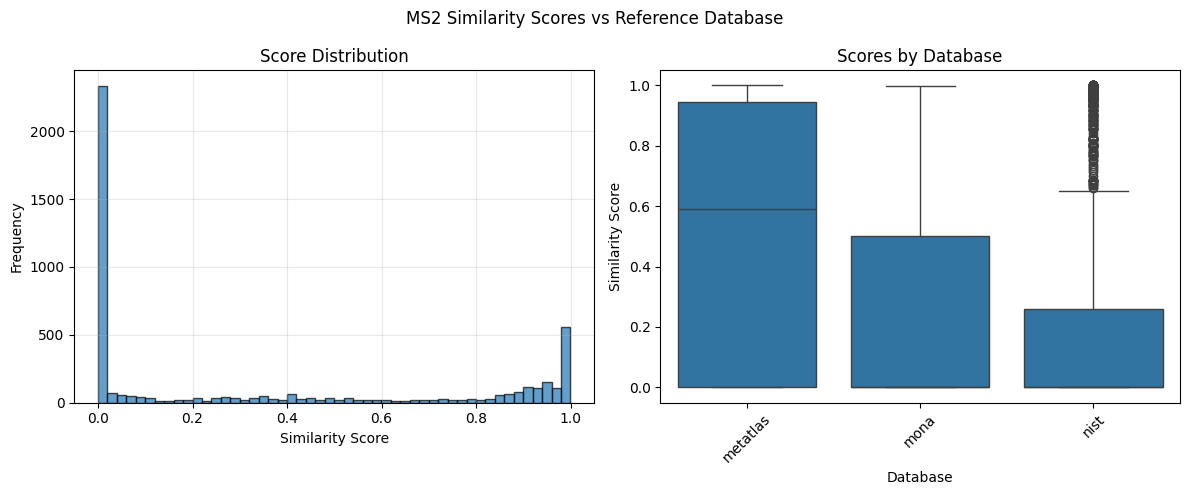

Score statistics:
  Mean: 0.341
  Median: 0.022
  Min: 0.000
  Max: 1.000
  Total hits: 4677
  Hits with score > 0.5: 1560
  Hits with score > 0.7: 1382
  Hits with score > 0.9: 1037

=== High-Quality Matches (Score >= 0.4, Matches >= 2) ===
Found 1734 high-quality matches


In [18]:
if not ms2_hits.empty:
    print("=== MS2 Hits Analysis Results ===")
    
    # Analyze the results
    analysis = analyze_ms2_hits_results(ms2_hits, min_score=0.3, min_matches=2)
    
    print(f"Analysis Summary:")
    for key, value in analysis.items():
        if key != 'top_matches_per_compound':
            print(f"  {key}: {value}")
    
    # Plot score distribution
    print(f"\n=== Score Distribution ===")
    plot_ms2_score_distribution(ms2_hits, "MS2 Similarity Scores vs Reference Database")
    
    # Filter high-quality matches
    print(f"\n=== High-Quality Matches (Score >= 0.4, Matches >= 2) ===")
    high_quality_hits = filter_ms2_hits(ms2_hits, min_score=0.4, min_matches=2)
    
    if not high_quality_hits.empty:
        print(f"Found {len(high_quality_hits)} high-quality matches")
        high_quality_hits_dict = {
            file_name: group.set_index(['id'])
            for file_name, group in high_quality_hits.reset_index().groupby('file_name')
        }
        ms2_data_with_hits = combine_ms2_data_and_hits(ms2_data, high_quality_hits_dict)
    else:
        print("No high-quality matches found")
        high_quality_hits_dict = {}
        
else:
    print("No MS2 hits data available. Please run the MS2 analysis first.")
    print("Make sure your ms2_data contains spectra and the reference database is loaded.")

# Set up targeted plotter

In [19]:
def suggest_rt_bounds_from_eic(eic_data, atlas_rt_peak, atlas_rt_min, atlas_rt_max):
    """
    Suggest new RT bounds based on sophisticated peak detection in EIC data.
    Uses scipy peak finding to identify peak boundaries and calculate confidence.
    
    Args:
        eic_data: Dictionary of file_name -> EIC trace data
        atlas_rt_peak: Original atlas RT peak
        atlas_rt_min: Original atlas RT min
        atlas_rt_max: Original atlas RT max
    
    Returns:
        dict: {'rt_min': float, 'rt_max': float, 'rt_peak': float, 'confidence': float}
        Returns None if no good suggestions can be made
    """
    from scipy.signal import find_peaks, peak_widths, peak_prominences
    from scipy.ndimage import gaussian_filter1d
    
    if not eic_data:
        return None
    
    # Find the EIC with highest peak intensity
    best_file = None
    best_intensity = 0
    
    for file_name, trace_data in eic_data.items():
        peak_intensity = trace_data.get('intensity_peak', 0)
        if peak_intensity and peak_intensity > best_intensity:
            best_intensity = peak_intensity
            best_file = file_name
    
    if best_file is None:
        return None
    
    trace_data = eic_data[best_file]
    rt_vals_raw = trace_data.get('rt_vals', [])
    i_vals_raw = trace_data.get('i_vals', [])
    
    # Clean and convert data to proper numeric arrays
    try:
        # Filter out None values and convert to numeric
        valid_indices = []
        rt_vals_clean = []
        i_vals_clean = []
        
        for i, (rt, intensity) in enumerate(zip(rt_vals_raw, i_vals_raw)):
            if rt is not None and intensity is not None:
                try:
                    rt_float = float(rt)
                    i_float = float(intensity)
                    if not np.isnan(rt_float) and not np.isnan(i_float) and i_float >= 0:
                        valid_indices.append(i)
                        rt_vals_clean.append(rt_float)
                        i_vals_clean.append(i_float)
                except (ValueError, TypeError):
                    continue
        
        if len(rt_vals_clean) < 5:
            return None
            
        rt_vals = np.array(rt_vals_clean, dtype=np.float64)
        i_vals = np.array(i_vals_clean, dtype=np.float64)
        
    except Exception as e:
        # If data cleaning fails, fall back to simple approach
        try:
            rt_vals = np.array([x for x in rt_vals_raw if x is not None], dtype=np.float64)
            i_vals = np.array([x for x in i_vals_raw if x is not None], dtype=np.float64)
            if len(rt_vals) != len(i_vals) or len(rt_vals) < 5:
                return None
        except:
            return None
    
    # Ensure we have enough data points and valid data
    if len(rt_vals) == 0 or len(i_vals) == 0 or len(rt_vals) < 5:
        return None
    
    if np.max(i_vals) <= 0:
        return None
    
    # Sort by RT to ensure proper order
    sort_idx = np.argsort(rt_vals)
    rt_vals = rt_vals[sort_idx]
    i_vals = i_vals[sort_idx]
    
    # Smooth the data slightly to reduce noise for peak detection
    try:
        i_vals_smooth = gaussian_filter1d(i_vals.astype(np.float64), sigma=1.0)
    except Exception:
        # If smoothing fails, use original data
        i_vals_smooth = i_vals.astype(np.float64)
    
    # Find all peaks with minimum height and prominence
    max_intensity = np.max(i_vals_smooth)
    min_height = max_intensity * 0.1  # At least 10% of max intensity
    min_prominence = max_intensity * 0.05  # At least 5% prominence
    
    try:
        peaks, peak_properties = find_peaks(
            i_vals_smooth, 
            height=min_height,
            prominence=min_prominence,
            distance=5  # Minimum 5 data points between peaks
        )
    except Exception:
        # If peak finding fails, find maximum manually
        max_idx = np.argmax(i_vals_smooth)
        peaks = np.array([max_idx])
    
    if len(peaks) == 0:
        return None
    
    # Find the peak closest to the atlas RT peak
    peak_rts = rt_vals[peaks]
    peak_intensities = i_vals_smooth[peaks]
    
    # Calculate score for each peak (combination of intensity and proximity to atlas)
    intensity_scores = peak_intensities / np.max(peak_intensities)
    rt_deviations = np.abs(peak_rts - atlas_rt_peak)
    max_expected_deviation = max(abs(atlas_rt_max - atlas_rt_min), 1.0)
    rt_scores = np.maximum(0.0, 1.0 - (rt_deviations / max_expected_deviation))
    
    # Combined score (weight intensity more heavily)
    combined_scores = 0.7 * intensity_scores + 0.3 * rt_scores
    best_peak_idx = np.argmax(combined_scores)
    selected_peak = peaks[best_peak_idx]
    
    # Get peak properties for the selected peak
    try:
        prominences = peak_prominences(i_vals_smooth, [selected_peak])[0]
        widths_result = peak_widths(i_vals_smooth, [selected_peak], rel_height=0.5)
        
        # Extract width information
        width_indices = widths_result[0][0]  # Width in indices
        left_idx = int(widths_result[2][0])  # Left boundary index
        right_idx = int(widths_result[3][0])  # Right boundary index
        
    except Exception:
        # If width calculation fails, use simple approach
        prominences = np.array([i_vals_smooth[selected_peak] * 0.5])
        width_indices = 10.0  # Default width
        left_idx = max(0, selected_peak - 10)
        right_idx = min(len(rt_vals) - 1, selected_peak + 10)
    
    # Ensure boundaries are within array bounds
    left_idx = max(0, left_idx)
    right_idx = min(len(rt_vals) - 1, right_idx)
    
    # Advanced peak boundary detection using derivative analysis
    def find_peak_boundaries(rt_vals, i_vals, peak_idx, initial_left, initial_right):
        """Find more precise peak boundaries using slope analysis"""
        
        try:
            # Calculate first derivative (gradient)
            gradient = np.gradient(i_vals)
            
            # Find where slope becomes very small (< 5% of max gradient)
            max_grad = np.max(np.abs(gradient))
            slope_threshold = max_grad * 0.05 if max_grad > 0 else 0.1
            
            # Search left from peak
            final_left = initial_left
            for i in range(peak_idx, max(0, peak_idx - 20), -1):
                if i < len(gradient) and abs(gradient[i]) < slope_threshold:
                    # Check if intensity has dropped significantly
                    if i_vals[i] < i_vals[peak_idx] * 0.1:  # Below 10% of peak
                        final_left = i
                        break
                    # Or if we're in a valley (derivative changes sign)
                    if i > 0 and gradient[i] * gradient[i-1] < 0 and gradient[i] > 0:
                        final_left = i
                        break
            
            # Search right from peak
            final_right = initial_right
            for i in range(peak_idx, min(len(gradient), peak_idx + 20)):
                if i < len(gradient) and abs(gradient[i]) < slope_threshold:
                    # Check if intensity has dropped significantly
                    if i_vals[i] < i_vals[peak_idx] * 0.1:  # Below 10% of peak
                        final_right = i
                        break
                    # Or if we're in a valley (derivative changes sign)
                    if i < len(gradient) - 1 and gradient[i] * gradient[i+1] < 0 and gradient[i] < 0:
                        final_right = i
                        break
            
            return final_left, final_right
            
        except Exception:
            # If derivative analysis fails, return initial boundaries
            return initial_left, initial_right
    
    # Apply advanced boundary detection
    refined_left, refined_right = find_peak_boundaries(
        rt_vals, i_vals_smooth, selected_peak, left_idx, right_idx
    )
    
    # Calculate suggested RT bounds with small padding
    base_rt_min = rt_vals[refined_left]
    base_rt_max = rt_vals[refined_right]
    
    # Add minimal padding (5% of peak width or 0.05 min, whichever is larger)
    peak_width_rt = base_rt_max - base_rt_min
    padding = max(0.05, peak_width_rt * 0.05)
    
    suggested_rt_peak = rt_vals[selected_peak]
    suggested_rt_min = base_rt_min - padding
    suggested_rt_max = base_rt_max + padding
    
    # Calculate comprehensive confidence score
    def calculate_confidence(peak_intensity, prominence, width_indices, rt_deviation, max_expected_dev):
        """Calculate confidence based on multiple peak quality metrics"""
        
        try:
            # Intensity score (normalized to 0-1)
            max_possible_intensity = np.max(i_vals_smooth)
            intensity_score = min(1.0, peak_intensity / max(max_possible_intensity, 1e3))
            
            # Prominence score (how well separated the peak is)
            prominence_score = min(1.0, prominence / max(peak_intensity * 0.5, 1e3))
            
            # Width score (prefer peaks that are not too narrow or too wide)
            # Optimal width is around 10-30 data points for chromatographic peaks
            optimal_width = 20
            width_score = 1.0 - min(1.0, abs(width_indices - optimal_width) / optimal_width)
            
            # RT proximity score
            rt_score = max(0.0, 1.0 - (rt_deviation / max(max_expected_dev, 1.0)))
            
            # Peak shape score (symmetry and sharpness)
            left_tail = selected_peak - refined_left
            right_tail = refined_right - selected_peak
            asymmetry = abs(left_tail - right_tail) / max(left_tail + right_tail, 1)
            shape_score = max(0.0, 1.0 - asymmetry)  # More symmetric = higher score
            
            # Weighted combination of all scores
            weights = {
                'intensity': 0.3,
                'prominence': 0.2,
                'width': 0.15,
                'rt_proximity': 0.2,
                'shape': 0.15
            }
            
            final_confidence = (
                weights['intensity'] * intensity_score +
                weights['prominence'] * prominence_score +
                weights['width'] * width_score +
                weights['rt_proximity'] * rt_score +
                weights['shape'] * shape_score
            )
            
            return min(1.0, max(0.0, final_confidence))
            
        except Exception:
            # If confidence calculation fails, return basic score
            return min(1.0, peak_intensity / max(np.max(i_vals_smooth), 1e3))
    
    # Calculate final confidence
    peak_intensity = i_vals_smooth[selected_peak]
    prominence = prominences[0] if len(prominences) > 0 else peak_intensity * 0.5
    rt_deviation = abs(suggested_rt_peak - atlas_rt_peak)
    
    confidence = calculate_confidence(
        peak_intensity, prominence, width_indices, rt_deviation, max_expected_deviation
    )
    
    # Additional quality checks
    if confidence < 0.1:  # Very low confidence
        return None
    
    if peak_width_rt > (atlas_rt_max - atlas_rt_min) * 2:  # Peak too wide
        confidence *= 0.5
    
    if rt_deviation > max_expected_deviation * 2:  # Peak too far from expected
        confidence *= 0.3
    
    return {
        'rt_min': float(suggested_rt_min),
        'rt_max': float(suggested_rt_max),
        'rt_peak': float(suggested_rt_peak),
        'confidence': float(confidence),
        'source_file': best_file,
        'peak_intensity': float(peak_intensity),
        'prominence': float(prominence),
        'peak_width_rt': float(peak_width_rt),
        'num_peaks_found': len(peaks)
    }

def set_up_plot_data(eics, atlas_df_ft, ms2_data_with_hits):
    """
    Build a complete compound metadata dictionary from EICs and atlas DataFrame.
    Returns a dictionary keyed by InChI key, with all EIC and MS2 info for plotting.
    """
    print("Building complete compound metadata dictionary...")

    metadata = {}

    for _, row in tqdm(atlas_df_ft.iterrows(), total=len(atlas_df_ft), desc="Processing compounds"):
        compound_name = row['label']
        compound_inchi = row['inchi_key']

        # Set up atlas data
        atlas_data = {
            'rt_min': row['rt_min'],
            'rt_max': row['rt_max'],
            'rt_peak': row['rt_peak'],
            'mz': row['mz'],
            'mz_tolerance': row.get('mz_tolerance_ppm', 10.0),
            'adduct': row.get('adduct', '[M+H]+'),
            'polarity': row.get('polarity', 'positive'),
            'compound_name': compound_name,
            'inchi_key': compound_inchi,
            'formula': row.get('formula', ''),
            'exact_mass': row.get('exact_mass', None)
        }

        # Initialize metadata structure
        metadata[compound_inchi] = {
            'original_atlas_data': atlas_data.copy(),
            'is_modified': False,
            'new_atlas_data': atlas_data.copy(),
            'suggested_atlas_data': None,  # Will be populated below
            'eic_data': {},
            'number_of_files': 0,
            'best_eic': {
                'file_peak': None,
                'rt_peak': None,
                'intensity_peak': None,
                'mz_peak': None,
                'ppm_diff': None,
                'rt_diff': None
            },
            'ms2_data': {}
        }

        # EIC extraction
        compound_eic_data = []
        for file_path, eic_df in eics.items():
            compound_eics = eic_df[eic_df['inchi_key'] == compound_inchi]
            if not compound_eics.empty:
                compound_eics = compound_eics.copy()
                compound_eics.loc[:, 'file_name'] = Path(file_path).name
                compound_eic_data.append(compound_eics)
        all_compound_eic_data = pd.concat(compound_eic_data, ignore_index=True) if compound_eic_data else pd.DataFrame()
        if not all_compound_eic_data.empty:
            all_compound_eic_data.sort_values(by=['intensity_peak'], ascending=False, inplace=True)
            # Store EIC traces as a dict of file_name: {rt_vals, i_vals}
            eic_dict = {}
            for _, eic_row in all_compound_eic_data.iterrows():
                # Sort RT and intensity values by RT ascending
                rt_vals = np.array(eic_row['rt'])
                i_vals = np.array(eic_row['i'])
                if len(rt_vals) > 1:
                    sort_idx = np.argsort(rt_vals)
                    rt_vals = rt_vals[sort_idx]
                    i_vals = i_vals[sort_idx]
                eic_dict[eic_row['file_name']] = {
                    'rt_vals': rt_vals,
                    'i_vals': i_vals,
                    'mz_vals': eic_row.get('mz', []),
                    'intensity_peak': eic_row.get('intensity_peak', None),
                    'rt_peak': eic_row.get('rt_peak', None),
                    'mz_peak': eic_row.get('mz_peak', None),
                    'rt_ms1_measured': eic_row.get('rt_peak', None),
                    'rt_theoretical': atlas_data['rt_peak'],
                    'ppm_diff': abs(eic_row.get('mz_peak') - atlas_data['mz']) / atlas_data['mz'] * 1e6,
                    'rt_diff': eic_row.get('rt_peak') - atlas_data['rt_peak']
                }

            # Best EIC (highest intensity)
            best_idx = all_compound_eic_data['intensity_peak'].idxmax()
            best_row = all_compound_eic_data.loc[best_idx]

            metadata[compound_inchi]['best_eic'] = {
                'file_peak': best_row['file_name'],
                'rt_peak': best_row['rt_peak'],
                'intensity_peak': best_row['intensity_peak'],
                'mz_peak': best_row['mz_peak'],
                'ppm_diff': abs(best_row['mz_peak'] - atlas_data['mz']) / atlas_data['mz'] * 1e6,
                'rt_diff': best_row['rt_peak'] - atlas_data['rt_peak']
            }
            metadata[compound_inchi]['eic_data'] = eic_dict
            metadata[compound_inchi]['number_of_files'] = len(eic_dict)
            
            # Calculate suggested RT bounds from EIC data
            suggested_bounds = suggest_rt_bounds_from_eic(
                eic_dict, 
                atlas_data['rt_peak'], 
                atlas_data['rt_min'], 
                atlas_data['rt_max']
            )
            metadata[compound_inchi]['suggested_atlas_data'] = suggested_bounds

        # MS2 experimental spectra and reference spectra (hits) - SIMPLIFIED STRUCTURE
        ms2_files_data = {}  # Changed to organize by file_name instead of file_path
        
        for file_path, ms2_datapoints in ms2_data_with_hits.items():
            file_name = Path(file_path).name
            extracted_spectra = []
            hit_pairs = []  # List of (query_spectrum, reference_spectrum) pairs
            
            for ms2_datum in ms2_datapoints:
                # Add experimental MS2 spectrum if inchi_key matches
                if ms2_datum.get('inchi_key', None) == compound_inchi:
                    spectrum = ms2_datum.get('spectrum', None)
                    if spectrum is not None and len(spectrum) == 2:
                        # Create experimental spectrum entry
                        exp_spectrum = {
                            'mz': np.array(spectrum[0]),
                            'intensity': np.array(spectrum[1]),
                            'precursor_mz': ms2_datum.get('precursor_mz', 0.0),
                            'precursor_intensity': ms2_datum.get('precursor_intensity', 0.0),
                            'rt': ms2_datum.get('rt', None),
                            'adduct': ms2_datum.get('adduct', ''),
                            'ppm_diff': abs(ms2_datum.get('precursor_mz', 0.0) - atlas_data['mz']) / atlas_data['mz'] * 1e6,
                        }
                        extracted_spectra.append(exp_spectrum)
                        
                        # Check for hits and create query/reference pairs
                        hits = ms2_datum.get('hits', [])
                        for hit in hits:
                            ref_spec = hit.get('msv_ref_aligned', None)
                            query_spec = hit.get('msv_query_aligned', None)
                            if ref_spec is not None and query_spec is not None and len(ref_spec) == 2 and len(query_spec) == 2:
                                # Compute frag_matches for query and reference
                                query_mz = np.array(query_spec[0])
                                query_intensity = np.array(query_spec[1])
                                ref_mz = np.array(ref_spec[0])
                                ref_intensity = np.array(ref_spec[1])

                                # For each query mz, check if there is a ref intensity at the same index that is nonzero and mz matches within 0.001
                                frag_matches_query = []
                                for n in range(len(query_mz)):
                                    if n < len(ref_intensity):
                                        if abs(query_mz[n] - ref_mz[n]) <= 0.001 and ref_intensity[n] > 0:
                                            frag_matches_query.append("green")
                                        else:
                                            frag_matches_query.append("red")
                                    else:
                                        frag_matches_query.append("red")

                                # For each ref mz, check if there is a query intensity at the same index that is nonzero and mz matches within 0.001
                                frag_matches_ref = []
                                for n in range(len(ref_mz)):
                                    if n < len(query_intensity):
                                        if abs(ref_mz[n] - query_mz[n]) <= 0.001 and query_intensity[n] > 0:
                                            frag_matches_ref.append("green")
                                        else:
                                            frag_matches_ref.append("red")
                                    else:
                                        frag_matches_ref.append("red")

                                query_spectrum = {
                                    'mz': query_mz,
                                    'intensity': query_intensity,
                                    'rt': hit.get('msms_scan', 0.0),
                                    'data_frags': hit.get('data_frags', 0),
                                    'frag_matches': frag_matches_query,
                                }
                                
                                reference_spectrum = {
                                    'mz': ref_mz,
                                    'intensity': ref_intensity,
                                    'precursor_mz': hit.get('precursor_mz', 0.0),
                                    'adduct': hit.get('adduct', ms2_datum.get('adduct', '')),
                                    'score': hit.get('score', 0.0),
                                    'database': hit.get('database', 'unknown'),
                                    'rt': hit.get('msms_scan', 0.0),
                                    'num_matches': hit.get('num_matches', 0),
                                    'ref_frags': hit.get('ref_frags', 0),
                                    'hit_info': {
                                        'rt_ms2_measured': hit.get('msms_scan', 0.0),
                                        'precursor_mz': ms2_datum.get('precursor_mz', 0.0),
                                        'mz_theoretical': hit.get('precursor_mz', 0.0),
                                        'mz_measured': hit.get('measured_precursor_mz', 0.0),
                                        'ppm_diff': abs(hit.get('precursor_mz', 0.0) - hit.get('measured_precursor_mz', 0.0)) / hit.get('measured_precursor_mz', 1.0) * 1e6,
                                    },
                                    'frag_matches': frag_matches_ref,
                                }
                                hit_pairs.append((query_spectrum, reference_spectrum))
            
            # Only add file data if there are spectra
            if extracted_spectra or hit_pairs:
                ms2_files_data[file_name] = {
                    'extracted_spectra': extracted_spectra,
                    'hit_pairs': hit_pairs,
                    'has_extracted': len(extracted_spectra) > 0,
                    'has_hits': len(hit_pairs) > 0
                }

        metadata[compound_inchi]['ms2_data'] = ms2_files_data
        metadata[compound_inchi]['ms2_data']['total_files'] = len(ms2_files_data)
        metadata[compound_inchi]['ms2_data']['has_any_data'] = len(ms2_files_data) > 0

    return metadata

def filter_ms2_experimental_spectra_by_rt(experimental_spectra, rt_min, rt_max):
    """
    Filter experimental MS2 spectra to only include those within the specified RT bounds.
    
    Parameters:
    experimental_spectra: List of experimental spectra dictionaries
    rt_min: Minimum retention time
    rt_max: Maximum retention time

    Returns:
    List of filtered experimental spectra
    """
    filtered_spectra = []

    for spectrum in experimental_spectra:
        spectrum_rt = spectrum.get('rt', spectrum.get('scan_time', None))
        
        # Only include spectra within RT bounds
        if spectrum_rt is not None and rt_min <= spectrum_rt <= rt_max:
            filtered_spectra.append(spectrum)

    return filtered_spectra

# def apply_rt_filtering_to_metadata(compound_metadata, rt_min, rt_max):
#     """
#     Apply RT filtering to MS2 experimental spectra in compound metadata.
#     This modifies the metadata in-place to store both original and filtered spectra.
    
#     Parameters:
#     compound_metadata: The complete compound metadata dictionary
#     rt_min: Minimum retention time
#     rt_max: Maximum retention time

#     Returns:
#     List of filtered experimental spectra
#     """
#     filtered_spectra = []

#     for spectrum in experimental_spectra:
#         spectrum_rt = spectrum.get('rt', spectrum.get('scan_time', None))
        
#         # Only include spectra within RT bounds
#         if spectrum_rt is not None and rt_min <= spectrum_rt <= rt_max:
#             filtered_spectra.append(spectrum)

#     return filtered_spectra

# def apply_rt_filtering_to_metadata(compound_metadata, rt_min, rt_max):
#     """
#     Apply RT filtering to MS2 experimental spectra in compound metadata.
#     This modifies the metadata in-place to store both original and filtered spectra.
    
#     Parameters:
#     compound_metadata: The complete compound metadata dictionary
#     rt_min: Minimum retention time
#     rt_max: Maximum retention time
#     """

#     # Apply RT filtering to all files in ms2_data
#     ms2_data = compound_metadata.get('ms2_data', {})
#     file_keys = [k for k in ms2_data.keys() if not k.startswith('has_')]
    
#     for file_key in file_keys:
#         file_ms2 = ms2_data[file_key]
        
#         # Filter extracted_data

#         if 'extracted_data' in file_ms2:
#             file_ms2['extracted_data'] = filter_ms2_experimental_spectra_by_rt(
#                 file_ms2['extracted_data'], rt_min, rt_max
#             )
        
#         # Filter hit_data experimental_spectra
#         if 'hit_data' in file_ms2 and 'experimental_spectra' in file_ms2['hit_data']:
#             file_ms2['hit_data']['experimental_spectra'] = filter_ms2_experimental_spectra_by_rt(
#                 file_ms2['hit_data']['experimental_spectra'], rt_min, rt_max
#             )
    
#     # Update has_data and has_hits flags based on filtered results
#     has_data = False
#     has_hits = False
    
#     for file_key in file_keys:
#         file_ms2 = ms2_data[file_key]
#         if file_ms2.get('extracted_data', []):
#             has_data = True
#         if file_ms2.get('hit_data', {}).get('experimental_spectra', []):
#             has_hits = True
    
#     compound_metadata['ms2_data']['has_data'] = has_data
#     compound_metadata['ms2_data']['has_hits'] = has_hits
    
#     return []  # Return empty list for backward compatibility

def write_ms2_title(compound_metadata, ms2_info, ms2_data_type, ms2_file):
    """Create MS2 title and subheadings"""
    
    # Create MS2 title (exact same format as original)
    name = compound_metadata['original_atlas_data']['compound_name']
    index = 1
    heading = f"{name} {index}"

    if ms2_data_type == 'hits':
        hit_info = ms2_info.get('hit_info', {})
        if hit_info:
            subheading1 = (
                f"Measured m/z: {hit_info['mz_measured']}  |  Reference m/z: {hit_info['mz_theoretical']}  |  "
                f"Reference DB: {ms2_info['database']}  |  Ref Matches: {ms2_info['num_matches']}  |  Score: {ms2_info['score']:.4f}"
            )
        else:
            subheading1 = (
                f'Measured m/z: N/A  |  Reference DB: N/A  |  Ref Matches: N/A  |  Score: N/A'
            )
    elif ms2_data_type == 'extracted':
        subheading1 = (
                    f"Measured m/z: {ms2_info.get('precursor_mz', 0.0)}  |  Theoretical m/z: {compound_metadata['original_atlas_data']['mz']}  |  "
                    f"Reference DB: N/A  |  Ref Matches: N/A  |  Score: N/A"
                )
    elif ms2_data_type is None:
        subheading1 = 'No MS2 data available'

    if ms2_file:
        subheading2 = f'Experimental: {ms2_file}'
    else:
        subheading2 = 'No file data'

    ms2_title = f'{heading}<br><sub>{subheading1}</sub><br><sub>{subheading2}</sub>'

    return ms2_title

def write_eic_title(compound_metadata):

    # Create EIC title (exact same format as original)
    eic_title_parts = []
    
    # Basic info
    if compound_metadata['original_atlas_data']['adduct']:
        eic_title_parts.append(f'Adduct: {compound_metadata["original_atlas_data"]["adduct"]}')
    if compound_metadata['original_atlas_data']['inchi_key']:
        eic_title_parts.append(f'InChI Key: {compound_metadata["original_atlas_data"]["inchi_key"]}')
    eic_title_parts.append(f'LCMS files: {compound_metadata["number_of_files"]}')
    subheading1 = ' | '.join(eic_title_parts)

    # RT and m/z comparison using CURRENT RT values
    rt_parts = [f'Atlas RT: {compound_metadata["original_atlas_data"]["rt_peak"]:.2f}']

    best_rt = compound_metadata['best_eic']['rt_peak']
    if best_rt is not None:
        # Recalculate RT diff using current RT peak
        current_rt_diff = abs(compound_metadata["original_atlas_data"]["rt_peak"] - best_rt)
        rt_parts.extend([
            f'Measured RT: {best_rt:.2f} min',
            f'RT diff: {current_rt_diff:.2f} min'
        ])
    else:
        rt_parts.extend(['Measured RT: N/A', 'RT diff: N/A'])
    
    rt_parts.append(f'Atlas m/z: {compound_metadata["original_atlas_data"]["mz"]:.4f}')
    
    best_mz = compound_metadata['best_eic']['mz_peak']
    if best_mz is not None:
        ppm_diff = compound_metadata['best_eic']['ppm_diff']
        rt_parts.extend([
            f'Measured m/z: {best_mz:.4f}',
            f'ppm diff: {ppm_diff:.2f}' if ppm_diff is not None else 'ppm diff: N/A'
        ])
    else:
        rt_parts.extend(['Measured m/z: N/A', 'ppm diff: N/A'])
    
    subheading2 = '   |   '.join(rt_parts)

    # Isomers
    isomers = ["Isomers", " not", " implemented"]
    #isomers = compound_metadata['isomers']
    subheading3 = f'Isomers: {", ".join(isomers)}' if isomers else 'No isomers'

    eic_title = f'<sub>{subheading1}</sub><br><sub>{subheading2}</sub><br><sub>{subheading3}</sub>'

    return eic_title

def create_targeted_analysis_plot(compound_metadata, 
                                  height=600, file_color_dict=None, 
                                  ms2_data_type=None, ms2_plot_data=None):
    """
    Create the plot using pre-calculated metadata and selected MS2 spectra.
    Args:
        ms2_plot_data: tuple (has_hits, has_data, selected_query, selected_ref)
    """

    current_rt_min, current_rt_max, current_rt_peak, is_modified = get_current_rt_bounds(compound_metadata)
    x_min = current_rt_min - 1.0
    x_max = current_rt_max + 1.0

    fig = make_subplots(
        rows=2, cols=1,
        row_heights=[0.4, 0.6],
        vertical_spacing=0.3,
        subplot_titles=('', ''),
        specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
    )
    eic_row = 2
    ms2_row = 1

    # MS2 plot logic
    selected_query, selected_ref, selected_file = ms2_plot_data
    exp_max_intensity = 0
    ref_max_intensity = 0
    max_mz = 0
    ms2_title = ""
    if ms2_data_type == 'hits':
        # Plot query (top) with hover info
        mz_vals = selected_query.get('mz', [])
        mz_colors = selected_query.get('frag_matches', [])
        intensity_vals = selected_query.get('intensity', [])
        if len(mz_vals) > 0 and len(intensity_vals) > 0:
            max_mz = max(max_mz, np.max(mz_vals))
            exp_max_intensity = max(exp_max_intensity, np.max(intensity_vals))
            
            # Create stick plot for experimental spectrum with per-stick color
            for mz, intensity, color in zip(mz_vals, intensity_vals, mz_colors):
                fig.add_trace(go.Scatter(
                    x=[mz, mz],
                    y=[0, intensity],
                    mode='lines',
                    line=dict(color=color, width=2),
                    showlegend=False, hoverinfo='skip', name='Experimental'
                ), row=ms2_row, col=1)
            
            # Add invisible markers at peak tops for hover interaction
            fig.add_trace(go.Scatter(
                x=list(mz_vals), y=list(intensity_vals),
                mode='markers',
                marker=dict(size=8, color="black", opacity=0.5),
                showlegend=False, name='Experimental Peaks',
                hovertemplate='m/z: %{x:.4f}<br>Intensity: %{y:.0f}<extra>Experimental</extra>'
            ), row=ms2_row, col=1)
        
        # Plot reference (bottom) with hover info
        mz_vals = selected_ref.get('mz', [])
        mz_colors = selected_ref.get('frag_matches', [])
        intensity_vals = selected_ref.get('intensity', [])
        if len(mz_vals) > 0 and len(intensity_vals) > 0:
            max_mz = max(max_mz, np.max(mz_vals))
            ref_max_intensity = max(ref_max_intensity, np.max(intensity_vals))
            # Scale reference intensities to match experimental scale
            if exp_max_intensity > 0 and ref_max_intensity > 0:
                scaled_intensities = [i * (exp_max_intensity / ref_max_intensity) for i in intensity_vals]
            else:
                scaled_intensities = intensity_vals

            # Create stick plot for reference spectrum with per-stick color
            for mz, scaled_int, color in zip(mz_vals, scaled_intensities, mz_colors):
                fig.add_trace(go.Scatter(
                    x=[mz, mz],
                    y=[0, -scaled_int],  # Negative for downward
                    mode='lines',
                    line=dict(color=color, width=2),
                    showlegend=False, hoverinfo='skip', name='Reference'
                ), row=ms2_row, col=1)

            # Add invisible markers at peak tops for hover interaction
            fig.add_trace(go.Scatter(
                x=list(mz_vals), y=[-s for s in scaled_intensities],
                mode='markers',
                marker=dict(size=8, color='red', opacity=0.5),
                showlegend=False, name='Reference Peaks',
                hovertemplate='m/z: %{x:.4f}<br>Intensity: %{customdata:.0f}<extra>Reference</extra>',
                customdata=list(intensity_vals)  # Use original intensities for hover
            ), row=ms2_row, col=1)
        
        ms2_title = write_ms2_title(compound_metadata, selected_ref, ms2_data_type, selected_file)
        
    elif ms2_data_type == 'extracted':
        # Plot only experimental spectrum (top) with hover info
        mz_vals = selected_query.get('mz', [])
        intensity_vals = selected_query.get('intensity', [])
        if len(mz_vals) > 0 and len(intensity_vals) > 0:
            max_mz = max(max_mz, np.max(mz_vals))
            exp_max_intensity = max(exp_max_intensity, np.max(intensity_vals))
            
            # Create stick plot for experimental spectrum
            x_coords = []
            y_coords = []
            for mz, intensity in zip(mz_vals, intensity_vals):
                x_coords.extend([mz, mz, None])
                y_coords.extend([0, intensity, None])
            
            fig.add_trace(go.Scatter(
                x=x_coords, y=y_coords, mode='lines',
                line=dict(color='blue', width=2),
                showlegend=False, hoverinfo='skip', name='Experimental'
            ), row=ms2_row, col=1)
            
            # Add invisible markers at peak tops for hover interaction
            fig.add_trace(go.Scatter(
                x=list(mz_vals), y=list(intensity_vals),
                mode='markers',
                marker=dict(size=8, color='blue', opacity=0.01),
                showlegend=False, name='Experimental Peaks',
                hovertemplate='m/z: %{x:.4f}<br>Intensity: %{y:.0f}<extra>Experimental</extra>'
            ), row=ms2_row, col=1)
        
        ms2_title = write_ms2_title(compound_metadata, selected_query, ms2_data_type, selected_file)

    # Configure MS2 subplot
    fig.update_xaxes(
        title_text="m/z",
        showgrid=False,
        range=[0, max_mz*1.1] if max_mz > 0 else [0, 500],
        row=ms2_row, col=1
    )
    y_range = [-exp_max_intensity * 1.1, exp_max_intensity * 1.1] if exp_max_intensity > 0 else [-1000, 1000]
    fig.update_yaxes(
        title_text="Intensity",
        showgrid=False,
        range=y_range,
        row=ms2_row, col=1
    )
    fig.add_hline(y=0, line_color="black", line_width=1, row=ms2_row, col=1)
    fig.add_vline(x=max_mz, line_dash="dash", line_color="black",
                    line_width=1, row=ms2_row, col=1)

    # Add EIC traces
    def get_file_color(file_name, color_dict, default_color="gray"):
        """Get color for file based on color dictionary or default"""
        if not color_dict:
            return default_color
        for key, color in color_dict.items():
            if key.lower() in file_name.lower():
                return color
        return default_color

    for file_name, trace_data in compound_metadata['eic_data'].items():
        color = get_file_color(file_name, file_color_dict)
        
        fig.add_trace(go.Scatter(
            x=trace_data['rt_vals'],
            y=trace_data['i_vals'],
            mode='lines',
            name=file_name,
            line=dict(color=color, width=2),
            hovertemplate=f'{file_name}<extra></extra>',
            showlegend=False
        ), row=eic_row, col=1)

    # Add RT reference lines using CURRENT working values
    fig.add_vline(x=current_rt_peak, line_dash="dash", line_color="black", line_width=3, row=eic_row, col=1)
    fig.add_vline(x=current_rt_min, line_dash="dot", line_color="red", line_width=2, row=eic_row, col=1)
    fig.add_vline(x=current_rt_max, line_dash="dot", line_color="blue", line_width=2, row=eic_row, col=1)

    # Add suggested RT bounds as a transparent gray box if available
    suggested_data = compound_metadata.get('suggested_atlas_data', None)
    if suggested_data is not None:
        #confidence = suggested_data.get('confidence', 0.0)
        rt_min = suggested_data['rt_min']
        rt_max = suggested_data['rt_max']
        # Add a transparent gray rectangle for suggested RT bounds
        fig.add_vrect(
            x0=rt_min,
            x1=rt_max,
            fillcolor="gray",
            opacity=0.15,
            line_width=0,
            row=eic_row,
            col=1
        )
        # Place the confidence annotation above the box, centered
        x_center = (rt_min + rt_max) / 2
        fig.add_annotation(
            x=x_center,
            yref=f'y{eic_row}',
            y=max(trace_data['i_vals']),  # slightly above the top of the plot
            xref=f'x{eic_row}',
            text="",
            #text=f"Conf: {confidence:.2f}",
            showarrow=False,
            font=dict(color="gray", size=12),
            align="center",
            xanchor="center",
            yanchor="bottom",
            row=eic_row,
            col=1
        )

    # Configure EIC subplot
    fig.update_xaxes(title_text='RT', 
                    range=[x_min, x_max],
                    showgrid=False, zeroline=False, showline=True,
                    linewidth=1, linecolor='black', ticks='outside',
                    tickwidth=1, tickcolor='black', row=eic_row, col=1)
    fig.update_yaxes(title_text='Intensity',
                    range=[0, None],
                    showgrid=False, zeroline=False, showline=True,
                    linewidth=1, linecolor='black', ticks='outside',
                    tickwidth=1, tickcolor='black', row=eic_row, col=1)
    
    eic_title = write_eic_title(compound_metadata)

    fig.add_annotation(
        text=eic_title,
        x=0.5, y=0.58,
        xref="paper", yref="paper",
        showarrow=False,
        font=dict(size=12),
        xanchor="center"
    )

    fig.add_annotation(
        text=ms2_title,
        x=0.5, y=1.1,
        xref="paper", yref="paper",
        showarrow=False,
        font=dict(size=12),
        xanchor="center"
    )

    # Final layout configuration
    fig.update_layout(
        margin=dict(l=50, r=50, t=50, b=50),
        hovermode='closest',
        height=height,
        #width=1000,
        showlegend=False,
        plot_bgcolor='white'
    )

    # Add scale toggle buttons
    updatemenus = [dict(
        type="buttons", direction="right",
        buttons=[
            dict(args=[{f"yaxis{eic_row}.type": "linear", f"yaxis{eic_row}.autorange": True}], 
                    label="Lin", method="relayout"),
            dict(args=[{f"yaxis{eic_row}.type": "log", f"yaxis{eic_row}.autorange": True}], 
                    label="Log", method="relayout")
        ],
        x=0.02, xanchor="left", y=0.02, yanchor="bottom",
        bgcolor="rgba(255,255,255,0.8)", bordercolor="gray", borderwidth=1
    )]
    
    fig.update_layout(updatemenus=updatemenus)

    return fig

def get_current_rt_bounds(compound_metadata):
    """
    Get the current RT bounds for a compound (either atlas defaults or user-modified values).
    
    Parameters:
    compound_metadata: The complete compound metadata dictionary

    Returns:
    tuple: (rt_min, rt_max, rt_peak, is_modified)
    """

    if compound_metadata['is_modified']:
        # Return modified RT bounds
        atlas_data = compound_metadata['new_atlas_data']
        return (
            atlas_data['rt_min'],
            atlas_data['rt_max'], 
            atlas_data['rt_peak'],
            True
        )
    else:
        # Return original atlas bounds
        atlas_data = compound_metadata['original_atlas_data']
        return (
            atlas_data['rt_min'],
            atlas_data['rt_max'],
            atlas_data['rt_peak'],
            False
        )

def update_compound_rt_bounds(compound_metadata, rt_min, rt_max):
    """
    Update RT bounds for a compound and mark it as modified.
    This provides the ability to quickly adjust RT bounds based on empirical data.
    
    Args:
        compound_metadata: The metadata dictionary
        rt_min: New RT minimum
        rt_max: New RT maximum  
        rt_peak: New RT peak (optional, will be clamped to bounds if not provided)
    """
    # Mark as modified and update the modified RT bounds
    compound_metadata['is_modified'] = True
    compound_metadata['new_atlas_data']['rt_min'] = rt_min
    compound_metadata['new_atlas_data']['rt_max'] = rt_max

def reset_compound_rt_bounds(compound_metadata):
    """
    Reset RT bounds for a compound back to original atlas values and clear modified flag.
    
    Args:
        compound_metadata: The metadata dictionary
    """
    
    # Clear the modified flag - this will make the compound use atlas values again
    compound_metadata['is_modified'] = False
    
    # Reset the modified values to atlas values (for consistency)
    compound_metadata['new_atlas_data'] = {
        'rt_min': compound_metadata['original_atlas_data']['rt_min'],
        'rt_max': compound_metadata['original_atlas_data']['rt_max'],
        'rt_peak': compound_metadata['original_atlas_data']['rt_peak']
    }

def get_updated_atlas_df(compound_metadata, original_atlas_df):
    """
    Create an updated atlas DataFrame with all user RT bound modifications.
    Only compounds marked as 'modified' will have changed values.
    
    Args:
        compound_metadata: The metadata dictionary with modification tracking
        original_atlas_df: The original atlas DataFrame
    
    Returns:
        DataFrame: Updated atlas with modified RT bounds
    """
    updated_atlas = original_atlas_df.copy()

    for compound_inchi, meta in compound_metadata.items():
        mask = updated_atlas['inchi_key'] == compound_inchi
        if mask.any() and meta['is_modified']:
            # Only update if compound has been manually modified
            modified_bounds = meta['new_atlas_data']
            updated_atlas.loc[mask, 'rt_min'] = modified_bounds['rt_min']
            updated_atlas.loc[mask, 'rt_max'] = modified_bounds['rt_max']
            updated_atlas.loc[mask, 'rt_peak'] = modified_bounds['rt_peak']
    
    return updated_atlas

def create_gui(compound_metadata, atlas_df, file_color_dict=None):
    """
    Create an enhanced RT editor that includes MS2 file browsing capability.
    This combines the RT editing functionality with the ability to scroll through MS2 files.
    
    Args:
        compound_metadata: Pre-calculated metadata dictionary
        atlas_df: Original atlas DataFrame
        file_color_dict: File color mapping
    
    Returns:
        ipywidgets container with enhanced RT editor and MS2 browser
    """
    
    # Set starting status
    compound_list = list(compound_metadata.keys())
    all_compound_names = [meta['original_atlas_data']['compound_name'] for meta in compound_metadata.values()]
    current_compound_index = [0]
    current_ms2_file_index = [0]
    updating = [False]  # Prevent recursive updates
    if not compound_list:
        print("No compounds found in metadata")
        return None

    # Create main widgets
    plot_output = widgets.Output(layout=widgets.Layout(width='100%', height=f'1000px'))
    prev_button = widgets.Button(description="◀ Prev", button_style='primary', layout=widgets.Layout(width='80px'))
    next_button = widgets.Button(description="Next ▶", button_style='primary', layout=widgets.Layout(width='80px'))
    counter_label = widgets.HTML(value=f"Compound 1 of {len(compound_list)}", layout=widgets.Layout(width='150px'))
    compound_dropdown = widgets.Dropdown(
        options=[(f"{i+1}: {name}", i) for i, name in enumerate(all_compound_names)],
        description='Jump to:', layout=widgets.Layout(width='400px')
    )
    
    # RT sliders
    rt_min_slider = widgets.FloatSlider(
        value=0.0, min=0.0, max=20.0, step=0.0001,
        description='min:', readout_format='.2f', layout=widgets.Layout(width='100%'),
        style={'description_width': '80px', 'handle_color': 'red'}
    )
    rt_max_slider = widgets.FloatSlider(
        value=0.0, min=0.0, max=20.0, step=0.0001,
        description='max:', readout_format='.2f', layout=widgets.Layout(width='100%'),
        style={'description_width': '80px', 'handle_color': 'blue'}
    )

    ms2_prev_button = widgets.Button(description="◀ Prev MS2", button_style='info', layout=widgets.Layout(width='100px'))
    ms2_next_button = widgets.Button(description="Next MS2 ▶", button_style='info', layout=widgets.Layout(width='100px'))
    ms2_counter_label = widgets.HTML(value="", layout=widgets.Layout(width='150px'))
    
    reset_button = widgets.Button(description="Reset to Original", button_style='warning', layout=widgets.Layout(width='200px'))
    accept_suggestions_button = widgets.Button(description="Accept Suggestions", button_style='success', layout=widgets.Layout(width='200px'))
    status_label = widgets.HTML(value="<b>Status:</b> Ready to edit RT bounds", layout=widgets.Layout(width='100%'))

    def get_current_compound():
        """Get current compound name and metadata"""
        idx = current_compound_index[0]
        if 0 <= idx < len(compound_list):
            compound_inchi = compound_list[idx]
            compound_name = compound_metadata[compound_inchi]['original_atlas_data']['compound_name']
            return compound_inchi, compound_name, compound_metadata[compound_inchi]
        return None, None
    
    def reset_ms2_file_index():
        """Reset MS2 file index to 0 when switching compounds"""
        current_ms2_file_index[0] = 0

    def get_selected_ms2_spectra(meta, current_ms2_file_index, rt_min, rt_max):
        """
        Returns the selected MS2 spectra for plotting and info for the title.
        Files are sorted by best score (highest to lowest) within RT bounds.
        Returns:
            ms2_data_type: str ('hits', 'extracted', or None)
            selected_query: dict or None
            selected_ref: dict or None  
            selected_file: str or None
        """
        # Get MS2 files data
        ms2_data = meta.get('ms2_data', {})
        if not ms2_data or ms2_data.get('total_files', 0) == 0:
            return None, None, None, None
        
        # Get file names (excluding metadata keys)
        file_names = [k for k in ms2_data.keys() if k not in ['total_files', 'has_any_data']]
        if not file_names:
            return None, None, None, None
        
        # Calculate best score for each file within RT bounds for sorting
        file_scores = []
        for file_name in file_names:
            file_data = ms2_data[file_name]
            
            # Filter spectra by RT bounds and get best score
            def filter_by_rt(spectra_list):
                return [s for s in spectra_list if rt_min <= s.get('rt', 0) <= rt_max]
            
            filtered_hit_pairs = [(q, r) for q, r in file_data.get('hit_pairs', []) 
                                 if rt_min <= q.get('rt', 0) <= rt_max]
            filtered_extracted = filter_by_rt(file_data.get('extracted_spectra', []))
            
            # Get best score for this file
            best_score = 0.0
            if filtered_hit_pairs:
                best_score = max(pair[1].get('score', 0) for pair in filtered_hit_pairs)
            elif filtered_extracted:
                # For extracted spectra without hits, use intensity as a proxy score
                # Normalize to 0-1 range to be comparable with similarity scores
                max_intensity = max(np.max(s.get('intensity', [0])) for s in filtered_extracted)
                best_score = min(max_intensity / 1e6, 1.0) if max_intensity > 0 else 0.0
            
            file_scores.append((file_name, best_score))
        
        # Sort files by score (highest first)
        file_scores.sort(key=lambda x: x[1], reverse=True)
        sorted_file_names = [name for name, score in file_scores]
        
        # Clamp file index and get selected file
        idx = min(current_ms2_file_index, len(sorted_file_names) - 1)
        selected_file = sorted_file_names[idx]
        file_data = ms2_data[selected_file]
        
        # Filter spectra by RT bounds
        def filter_by_rt(spectra_list):
            return [s for s in spectra_list if rt_min <= s.get('rt', 0) <= rt_max]
        
        # Check what type of data we have and select best spectrum
        filtered_hit_pairs = [(q, r) for q, r in file_data.get('hit_pairs', []) 
                             if rt_min <= q.get('rt', 0) <= rt_max]
        filtered_extracted = filter_by_rt(file_data.get('extracted_spectra', []))
        
        if filtered_hit_pairs:
            # Sort hit pairs by reference spectrum score (highest first)
            filtered_hit_pairs.sort(key=lambda pair: pair[1].get('score', 0), reverse=True)
            query_spec, ref_spec = filtered_hit_pairs[0]
            return 'hits', query_spec, ref_spec, selected_file
        elif filtered_extracted:
            # Sort extracted spectra by intensity (highest first) 
            filtered_extracted.sort(key=lambda s: np.max(s.get('intensity', [0])), reverse=True)
            return 'extracted', filtered_extracted[0], None, selected_file
        else:
            return None, None, None, selected_file

    def create_figures():
        """Create plot with current compound and selected MS2 file"""
        if updating[0]:
            return

        compound_inchi, compound_name, meta = get_current_compound()
        if compound_inchi is None or meta is None:
            return

        plot_output.clear_output(wait=True)

        # Get RT bounds for MS2 filtering
        rt_min, rt_max, rt_peak, is_modified = get_current_rt_bounds(meta)

        # Get MS2 selection info (now sorted by score)
        ms2_data_type, query_spec, ref_spec, ms2_file = get_selected_ms2_spectra(meta, 
                                                                                current_ms2_file_index[0],
                                                                                rt_min,
                                                                                rt_max)

        # Update MS2 counter label with better information including score
        ms2_data = meta.get('ms2_data', {})
        total_files = ms2_data.get('total_files', 0)
        if total_files > 0:
            file_names = [k for k in ms2_data.keys() if k not in ['total_files', 'has_any_data']]
            current_file_idx = min(current_ms2_file_index[0], len(file_names) - 1)
            ms2_counter_label.value = f"MS2 File {current_file_idx + 1} of {total_files}"
        else:
            ms2_counter_label.value = "No MS2 data"

        # Create plot using the new logic
        fig = create_targeted_analysis_plot(
            compound_metadata=meta,
            file_color_dict=file_color_dict,
            ms2_data_type=ms2_data_type,
            ms2_plot_data=(query_spec, ref_spec, ms2_file)
        )

        # Update RT sliders based on current compound
        update_sliders()

        if fig is not None:
            with plot_output:
                fig.show()

    def enhanced_on_slider_change(change):
        """Enhanced slider change handler with MS2 RT filtering"""
        if updating[0]:
            return
        
        compound_inchi, compound_name, meta = get_current_compound()
        if compound_inchi is None or meta is None:
            return
        
        # Get current slider values
        new_rt_min = rt_min_slider.value
        new_rt_max = rt_max_slider.value
        
        # Check if values have changed from original atlas
        original_min = meta['original_atlas_data']['rt_min']
        original_max = meta['original_atlas_data']['rt_max']
        changed_from_atlas = (abs(new_rt_min - original_min) > 0.0001 or abs(new_rt_max - original_max) > 0.0001)
        
        if changed_from_atlas:
            # Update RT metadata when sliders change from atlas values
            update_compound_rt_bounds(meta, new_rt_min, new_rt_max)
        else:
            # If values match atlas, reset to unmodified state
            reset_compound_rt_bounds(meta)
        
        # Update plot
        create_figures()

        # Update status based on current state
        rt_min, rt_max, rt_peak, is_modified = get_current_rt_bounds(meta)
        
        if is_modified:
            status_text = f"<b>Status:</b> <span style='color: orange;'>MODIFIED</span> RT bounds for {compound_name} (min: {rt_min:.3f}, max: {rt_max:.3f})"
        else:
            status_text = f"<b>Status:</b> <span style='color: green;'>Atlas default</span> RT bounds for {compound_name}"
        status_label.value = status_text

    def update_sliders():
        """Update slider values from current compound RT bounds"""

        compound_inchi, compound_name, meta = get_current_compound()
        if compound_inchi is None or meta is None:
            return
        
        updating[0] = True
        try:
            rt_min_slider.unobserve_all()
            rt_max_slider.unobserve_all()

            # Get CURRENT RT bounds (either modified or atlas default)
            rt_min, rt_max, rt_peak, is_modified = get_current_rt_bounds(meta)
            atlas_data = meta['original_atlas_data']

            # Set slider ranges based on atlas bounds with extra margin
            x_min = rt_min - 1.0
            x_max = rt_max + 1.0            
            # x_min = atlas_data['rt_min'] - 1.0
            # x_max = atlas_data['rt_max'] + 1.0
            
            with rt_min_slider.hold_sync():
                rt_min_slider.min = x_min
                rt_min_slider.max = x_max
                rt_min_slider.value = rt_min  # Use current RT bounds
            
            with rt_max_slider.hold_sync():
                rt_max_slider.min = x_min
                rt_max_slider.max = x_max
                rt_max_slider.value = rt_max  # Use current RT bounds

            rt_min_slider.observe(enhanced_on_slider_change, names='value')
            rt_max_slider.observe(enhanced_on_slider_change, names='value')
            
            # Update status to reflect current state
            if is_modified:
                status_text = f"<b>Status:</b> <span style='color: orange;'>MODIFIED</span> RT bounds for {compound_name} (min: {rt_min:.3f}, max: {rt_max:.3f})"
            else:
                status_text = f"<b>Status:</b> <span style='color: green;'>Atlas default</span> RT bounds for {compound_name}"
            status_label.value = status_text
            
        finally:
            updating[0] = False

    def on_navigation(direction):
        """Handle compound navigation"""
        idx = current_compound_index[0] + direction
        if 0 <= idx < len(compound_list):
            updating[0] = True
            try:
                current_compound_index[0] = idx
                counter_label.value = f"Compound {idx+1} of {len(compound_list)}"
                
                # Reset MS2 file index when switching compounds
                reset_ms2_file_index()
                
                compound_dropdown.unobserve_all()
                compound_dropdown.value = idx
                compound_dropdown.observe(on_dropdown_change)
                
                update_sliders()
            finally:
                updating[0] = False
            
            create_figures()

    def on_dropdown_change(change):
        """Handle compound dropdown changes"""
        if change['name'] == 'value' and not updating[0]:
            updating[0] = True
            try:
                idx = change['new']
                current_compound_index[0] = idx
                counter_label.value = f"Compound {idx+1} of {len(compound_list)}"
                
                # Reset MS2 file index when switching compounds
                reset_ms2_file_index()
                
                update_sliders()
            finally:
                updating[0] = False
            
            create_figures()

    def on_ms2_navigation(direction):
        """Handle MS2 file navigation (now sorted by score)"""
        compound_inchi, _, meta = get_current_compound()
        if compound_inchi is None or meta is None:
            return

        ms2_data = meta.get('ms2_data', {})
        total_files = ms2_data.get('total_files', 0)
        if total_files == 0:
            return

        new_idx = current_ms2_file_index[0] + direction
        # Proper bounds checking - files are now sorted by score
        if 0 <= new_idx < total_files:
            current_ms2_file_index[0] = new_idx
            create_figures()  # This will update everything including the counter

    def on_reset(button):
        """Reset current compound to original RT bounds"""
        compound_inchi, compound_name, meta = get_current_compound()
        
        if compound_inchi is None:
            return
        
        reset_compound_rt_bounds(meta)
        update_sliders()
        create_figures()
        status_label.value = f"<b>Status:</b> Reset {compound_name} to original RT bounds"

    def on_accept_suggestions(button):
        """Accept suggested RT bounds for current compound"""
        compound_inchi, compound_name, meta = get_current_compound()
        
        if compound_inchi is None or meta is None:
            return
        
        suggested_data = meta.get('suggested_atlas_data', None)
        if suggested_data is None:
            status_label.value = f"<b>Status:</b> No suggestions available for {compound_name}"
            return
        
        # Set the updating flag to prevent any recursive calls
        updating[0] = True
        
        try:
            # Directly update the compound RT bounds
            suggested_rt_min = suggested_data['rt_min']
            suggested_rt_max = suggested_data['rt_max']
            
            # Update compound metadata directly
            update_compound_rt_bounds(meta, suggested_rt_min, suggested_rt_max)
            
            # Reset MS2 file index since RT bounds changed
            reset_ms2_file_index()
            
            # Prepare final status message 
            confidence = suggested_data.get('confidence', 0)
            final_status = f"<b>Status:</b> <span style='color: green;'>Accepted suggestions</span> for {compound_name} (confidence: {confidence:.2f})"

        finally:
            # Clear updating flag
            updating[0] = False
        
        # Now just call create_figures() normally - it will handle everything including sliders
        create_figures()
        
        # Set the final status message immediately after create_figures() completes
        # This ensures it overwrites any status set by update_sliders()
        status_label.value = final_status

    def enhanced_on_slider_change(change):
        """Enhanced slider change handler with MS2 RT filtering"""
        if updating[0]:
            return
        
        compound_inchi, compound_name, meta = get_current_compound()
        if compound_inchi is None or meta is None:
            return
        
        # Get current slider values
        new_rt_min = rt_min_slider.value
        new_rt_max = rt_max_slider.value
        
        # Check if values have changed from original atlas
        original_min = meta['original_atlas_data']['rt_min']
        original_max = meta['original_atlas_data']['rt_max']
        changed_from_atlas = (abs(new_rt_min - original_min) > 0.0001 or abs(new_rt_max - original_max) > 0.0001)
        
        if changed_from_atlas:
            # Update RT metadata when sliders change from atlas values
            update_compound_rt_bounds(meta, new_rt_min, new_rt_max)
        else:
            # If values match atlas, reset to unmodified state
            reset_compound_rt_bounds(meta)
        
        # Update plot
        create_figures()

        # Update status based on current state
        rt_min, rt_max, rt_peak, is_modified = get_current_rt_bounds(meta)
        
        if is_modified:
            status_text = f"<b>Status:</b> <span style='color: orange;'>MODIFIED</span> RT bounds for {compound_name} (min: {rt_min:.3f}, max: {rt_max:.3f})"
        else:
            status_text = f"<b>Status:</b> <span style='color: green;'>Atlas default</span> RT bounds for {compound_name}"
        status_label.value = status_text

    def update_sliders():
        """Update slider values from current compound RT bounds"""

        compound_inchi, compound_name, meta = get_current_compound()
        if compound_inchi is None or meta is None:
            return
        
        # Store the current updating state to restore it later
        was_updating = updating[0]
        updating[0] = True
        try:
            rt_min_slider.unobserve_all()
            rt_max_slider.unobserve_all()

            # Get CURRENT RT bounds (either modified or atlas default)
            rt_min, rt_max, rt_peak, is_modified = get_current_rt_bounds(meta)

            # Set slider ranges based on atlas bounds with extra margin
            x_min = rt_min - 1.0
            x_max = rt_max + 1.0            
            
            with rt_min_slider.hold_sync():
                rt_min_slider.min = x_min
                rt_min_slider.max = x_max
                rt_min_slider.value = rt_min  # Use current RT bounds
            
            with rt_max_slider.hold_sync():
                rt_max_slider.min = x_min
                rt_max_slider.max = x_max
                rt_max_slider.value = rt_max  # Use current RT bounds

            rt_min_slider.observe(enhanced_on_slider_change, names='value')
            rt_max_slider.observe(enhanced_on_slider_change, names='value')
            
            # Only update status if we're not in the middle of navigation
            # This prevents overwriting status messages set by navigation functions
            if not was_updating:
                # Update status to reflect current state and suggestions
                suggested_data = meta.get('suggested_atlas_data', None)
                if is_modified:
                    status_text = f"<b>Status:</b> <span style='color: orange;'>MODIFIED</span> RT bounds for {compound_name} (min: {rt_min:.3f}, max: {rt_max:.3f})"
                else:
                    status_text = f"<b>Status:</b> <span style='color: green;'>Atlas default</span> RT bounds for {compound_name}"
                    
                if suggested_data:
                    confidence = suggested_data.get('confidence', 0)
                    status_text += f" | Suggestions available (confidence: {confidence:.2f})"
                status_label.value = status_text
            
        finally:
            updating[0] = was_updating  # Restore the original updating state

    def on_navigation(direction):
        """Handle compound navigation"""
        idx = current_compound_index[0] + direction
        if 0 <= idx < len(compound_list):
            updating[0] = True
            try:
                current_compound_index[0] = idx
                counter_label.value = f"Compound {idx+1} of {len(compound_list)}"
                
                # Reset MS2 file index when switching compounds
                reset_ms2_file_index()
                
                compound_dropdown.unobserve_all()
                compound_dropdown.value = idx
                compound_dropdown.observe(on_dropdown_change)
                
                update_sliders()
            finally:
                updating[0] = False
            
            create_figures()

    def on_dropdown_change(change):
        """Handle compound dropdown changes"""
        if change['name'] == 'value' and not updating[0]:
            updating[0] = True
            try:
                idx = change['new']
                current_compound_index[0] = idx
                counter_label.value = f"Compound {idx+1} of {len(compound_list)}"
                
                # Reset MS2 file index when switching compounds
                reset_ms2_file_index()
                
                update_sliders()
            finally:
                updating[0] = False
            
            create_figures()

    def on_ms2_navigation(direction):
        """Handle MS2 file navigation (now sorted by score)"""
        compound_inchi, _, meta = get_current_compound()
        if compound_inchi is None or meta is None:
            return

        ms2_data = meta.get('ms2_data', {})
        total_files = ms2_data.get('total_files', 0)
        if total_files == 0:
            return

        new_idx = current_ms2_file_index[0] + direction
        # Proper bounds checking - files are now sorted by score
        if 0 <= new_idx < total_files:
            current_ms2_file_index[0] = new_idx
            create_figures()  # This will update everything including the counter

    def on_reset(button):
        """Reset current compound to original RT bounds"""
        compound_inchi, compound_name, meta = get_current_compound()
        
        if compound_inchi is None:
            return
        
        reset_compound_rt_bounds(meta)
        update_sliders()
        create_figures()
        status_label.value = f"<b>Status:</b> Reset {compound_name} to original RT bounds"

    # Connect event handlers
    prev_button.on_click(lambda b: on_navigation(-1))
    next_button.on_click(lambda b: on_navigation(1))
    compound_dropdown.observe(on_dropdown_change)
    ms2_prev_button.on_click(lambda b: on_ms2_navigation(-1))
    ms2_next_button.on_click(lambda b: on_ms2_navigation(1))
    reset_button.on_click(on_reset)
    accept_suggestions_button.on_click(on_accept_suggestions)

    # Create layout
    nav_row = widgets.HBox([prev_button, counter_label, next_button], layout=widgets.Layout(justify_content='center'))
    dropdown_row = widgets.HBox([compound_dropdown], layout=widgets.Layout(justify_content='center', margin='0 0 0 0'))
    
    # MS2 browser row
    ms2_nav_row = widgets.HBox([ms2_prev_button, ms2_counter_label, ms2_next_button], layout=widgets.Layout(justify_content='center'))

    # Put compound nav and ms2 nav side by side on the top of the plot
    nav_box = widgets.HBox([dropdown_row, nav_row, ms2_nav_row], layout=widgets.Layout(justify_content='space-between', width='100%'))
    
    rt_sliders_box = widgets.VBox([rt_min_slider, rt_max_slider], layout=widgets.Layout(width='100%', align_items='center', margin='-350px 0 0 0'))
    button_row = widgets.HBox([reset_button, accept_suggestions_button], layout=widgets.Layout(justify_content='center'))
    status_row = widgets.HBox([status_label], layout=widgets.Layout(justify_content='center'))

    container = widgets.VBox([
        nav_box, 
        #dropdown_row,
        #ms2_nav_row,
        plot_output, 
        rt_sliders_box, 
        button_row,
        status_row
    ], layout=widgets.Layout(width='100%', align_items='center'))
    
    # Add helper methods
    container.get_modified_atlas = lambda: get_updated_atlas_df(compound_metadata, atlas_df)
    container.metadata = compound_metadata

    # Initialize
    updating[0] = True
    try:
        update_sliders()
    finally:
        updating[0] = False
    
    create_figures()
    
    return container

In [20]:
file_color_dict = {
    'ISTD': 'blue',
    'ExCtrl': 'red', 
    'InjBl': 'orange',
}

plot_data = set_up_plot_data(eics, atlas_df_ft, ms2_data_with_hits)

Building complete compound metadata dictionary...


Processing compounds:   0%|          | 0/65 [00:00<?, ?it/s]

In [21]:
gui = create_gui(
    compound_metadata=plot_data,
    atlas_df=atlas_df_ft,
    file_color_dict=file_color_dict
)
display(gui)